In [1]:
# =============================================================================
# MODELO PREDICTIVO PARA EVALUACIÓN DEL DESEMPEÑO Y DETECCIÓN DE ANOMALÍAS
# EN SISTEMAS DE TRATAMIENTO DE AGUA DE PRODUCCIÓN
# =============================================================================
# Máster Universitario en Transformación Digital a través de Tecnologías Disruptivas
# Universidad Internacional de La Rioja (UNIR)
# Autores: Fredy Muñoz Bermúdez | Ivan D Mejia Segura | Jorge Andrés Suárez C
# Director: Gabriel Pares Mahedero
# Fecha: 2026
# =============================================================================

# -----------------------------------------------------------------------------
# INSTALACIÓN DE LIBRERÍAS (ejecutar solo en Google Colab)
# -----------------------------------------------------------------------------
# !pip install imbalanced-learn xgboost -q

# -----------------------------------------------------------------------------
# SECCIÓN 1: CARGA DE DATOS Y EXPLORACIÓN INICIAL (EDA)
# -----------------------------------------------------------------------------
# Objetivo: Entender la estructura, calidad y distribución del dataset antes
# de aplicar cualquier transformación. Esta etapa corresponde a las fases
# "Business Understanding" y "Data Understanding" de la metodología CRISP-DM.
# -----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# -----------------------------------------------------------------------------
# 1.1 CARGA DEL DATASET
# -----------------------------------------------------------------------------
# En Google Colab: montar Google Drive y ajustar la ruta al archivo Excel.
from google.colab import drive
drive.mount('/content/drive')

CARPETA    = '/content/drive/MyDrive/TFM/'
RUTA_DATOS = CARPETA + 'template_modelo_filtros _SST_GYA_TURBIDEZ.xlsx'

df = pd.read_excel(RUTA_DATOS)

print("=" * 60)
print("CARGA DEL DATASET")
print("=" * 60)
print(f"  Filas:    {df.shape[0]}")
print(f"  Columnas: {df.shape[1]}")
print(f"  Variables: {list(df.columns)}")

# -----------------------------------------------------------------------------
# 1.2 ESTRUCTURA Y TIPOS DE DATOS
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("ESTRUCTURA Y TIPOS DE DATOS")
print("=" * 60)
print(df.dtypes)
print("\nPrimeras 5 filas:")
print(df.head())

# -----------------------------------------------------------------------------
# 1.3 RANGO TEMPORAL
# -----------------------------------------------------------------------------
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
print("\n" + "=" * 60)
print("RANGO TEMPORAL")
print("=" * 60)
print(f"  Fecha mínima: {df['fecha'].min().strftime('%d/%m/%Y')}")
print(f"  Fecha máxima: {df['fecha'].max().strftime('%d/%m/%Y')}")
print("\n  Registros por año:")
print(df['fecha'].dt.year.value_counts().sort_index().to_string())

# Nota: se identifica un gap de datos entre 2019 y 2025 que será documentado
# en la sección de limitaciones del trabajo.

# -----------------------------------------------------------------------------
# 1.4 VALORES FALTANTES Y VALORES ESPECIALES (NR / ND)
# -----------------------------------------------------------------------------
# NR = No Reportado (fallo de medición) → se tratará como dato ausente (NaN)
# ND = No Detectado (valor bajo umbral)  → se tratará como 0

print("\n" + "=" * 60)
print("VALORES FALTANTES Y ESPECIALES")
print("=" * 60)

nulos = df.isnull().sum()
print("\n  Nulos por columna (celdas vacías):")
print(nulos[nulos > 0].to_string())

for col in ['grasas', 'turbidez']:
    nr = (df[col] == 'NR').sum()
    nd = (df[col] == 'ND').sum() if col == 'grasas' else 0
    if nr > 0 or nd > 0:
        print(f"\n  Valores especiales en '{col}':")
        print(f"    NR (No Reportado): {nr}")
        if nd > 0:
            print(f"    ND (No Detectado): {nd}")

# -----------------------------------------------------------------------------
# 1.5 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: Calidad")
print("=" * 60)
conteo = df['Calidad'].value_counts()
print(conteo.to_string())
print(f"\n  Ratio Mala/Buena: {conteo['Mala'] / conteo['Buena']:.1f}:1")
print("  → Desbalanceo severo. Se aplicará SMOTE en la fase de modelado.")

# -----------------------------------------------------------------------------
# 1.6 ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS
# -----------------------------------------------------------------------------
# Se convierten grasas y turbidez a numérico para el análisis descriptivo,
# reemplazando provisionalmente NR y ND por NaN.
df_desc = df.copy()
for col in ['grasas', 'turbidez']:
    df_desc[col] = pd.to_numeric(
        df_desc[col].replace({'NR': np.nan, 'ND': np.nan}), errors='coerce'
    )

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(df_desc[['SST', 'grasas', 'turbidez']].describe().round(3).to_string())

# -----------------------------------------------------------------------------
# 1.7 VISUALIZACIONES EDA
# -----------------------------------------------------------------------------

# --- Figura 1: Distribución de la variable objetivo ---
fig, ax = plt.subplots(figsize=(5, 4))
colores = {'Buena': '#4CAF50', 'Mala': '#E53935'}
conteo.plot(kind='bar', ax=ax, color=[colores[c] for c in conteo.index],
            edgecolor='white', width=0.5)
ax.set_title('Distribución de la variable objetivo\n(Calidad del agua tratada)')
ax.set_xlabel('Calidad')
ax.set_ylabel('Número de registros')
ax.set_xticklabels(conteo.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(CARPETA + 'fig1_distribucion_calidad.png', bbox_inches='tight')
plt.show()
print("  Figura 1 guardada: fig1_distribucion_calidad.png")

# --- Figura 2: Distribuciones de variables numéricas por clase ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
variables = ['SST', 'grasas', 'turbidez']
unidades  = ['mg/L', 'mg/L', 'NTU']

for ax, var, unidad in zip(axes, variables, unidades):
    for clase, color in [('Buena', '#4CAF50'), ('Mala', '#E53935')]:
        datos = pd.to_numeric(
            df_desc[df_desc['Calidad'] == clase][var].replace({'NR': np.nan, 'ND': np.nan}),
            errors='coerce'
        ).dropna()
        ax.hist(datos, bins=25, alpha=0.6, color=color, label=clase, edgecolor='white')
    ax.set_title(f'Distribución de {var}')
    ax.set_xlabel(f'{var} ({unidad})')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Distribución de variables numéricas por clase de calidad', y=1.02)
plt.tight_layout()
plt.savefig(CARPETA + 'fig2_distribuciones_variables.png', bbox_inches='tight')
plt.show()
print("  Figura 2 guardada: fig2_distribuciones_variables.png")

# --- Figura 3: Registros por año ---
fig, ax = plt.subplots(figsize=(7, 4))
registros_año = df['fecha'].dt.year.value_counts().sort_index()
ax.bar(registros_año.index.astype(str), registros_año.values,
       color='#2E75B6', edgecolor='white')
ax.set_title('Registros por año\n(Identificación del gap temporal 2020–2024)')
ax.set_xlabel('Año')
ax.set_ylabel('Número de registros')
ax.axvspan(-0.5, 3.5, alpha=0.05, color='green', label='Datos 2016–2019')
ax.axvspan(3.5, 5.5, alpha=0.08, color='red', label='Gap 2020–2024 (sin datos)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(CARPETA + 'fig3_registros_por_año.png', bbox_inches='tight')
plt.show()
print("  Figura 3 guardada: fig3_registros_por_año.png")

# --- Figura 4: Top 10 facilidades por número de registros ---
fig, ax = plt.subplots(figsize=(8, 4))
top10 = df['Facilidad'].value_counts().head(10)
top10.plot(kind='barh', ax=ax, color='#2E75B6', edgecolor='white')
ax.set_title('Top 10 facilidades por número de registros')
ax.set_xlabel('Número de registros')
ax.set_ylabel('Facilidad')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(CARPETA + 'fig4_top10_facilidades.png', bbox_inches='tight')
plt.show()
print("  Figura 4 guardada: fig4_top10_facilidades.png")

print("\n" + "=" * 60)
print("SECCIÓN 1 COMPLETADA")
print("Resumen de hallazgos:")
print("  - Dataset: 502 registros, 7 variables, solo Estación 1")
print("  - Gap temporal: sin datos entre 2020 y 2024")
print("  - Desbalanceo de clases: 10.7:1 (Mala/Buena)")
print("  - Valores especiales: NR y ND en grasas y turbidez")
print("  - Nulos relevantes: SST 11%, grasas 4.6%, turbidez 5%")
print("=" * 60)
print("Continuar con Sección 2: Preprocesamiento")


ModuleNotFoundError: No module named 'google.colab'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SECCIÓN 2: PREPROCESAMIENTO DE DATOS
  Dataset cargado: 502 filas x 7 columnas

  [2.2] Columna 'estacion' eliminada (varianza = 0, valor único).
  [2.3] Variables 'año' y 'mes' extraídas de la columna fecha.
  [2.4] Valores especiales tratados:
        grasas  → NR(12)→NaN | ND(7)→0.0 | Flags creados.
        turbidez → NR(20)→NaN | Flag creado.

  [2.5] Imputación de nulos (mediana por Facilidad+Calidad):
        SST: 55 nulos → 0 nulos restantes.
        grasas: 16 nulos → 0 nulos restantes.
        turbidez: 25 nulos → 0 nulos restantes.
  [2.6] Winsorizing 'SST': 12 valores recortados → rango [1.05, 188.68]
  [2.6] Winsorizing 'grasas': 6 valores recortados → rango [0.00, 404.22]
  [2.6] Winsorizing 'turbidez': 12 valores recortados → rango [0.60, 114.99]

  [2.7] Encoding de 'Facilidad':
        58 categorías → 9 tipos: ['CPI', 'CPL', 'CPN', 'Celda', 'E

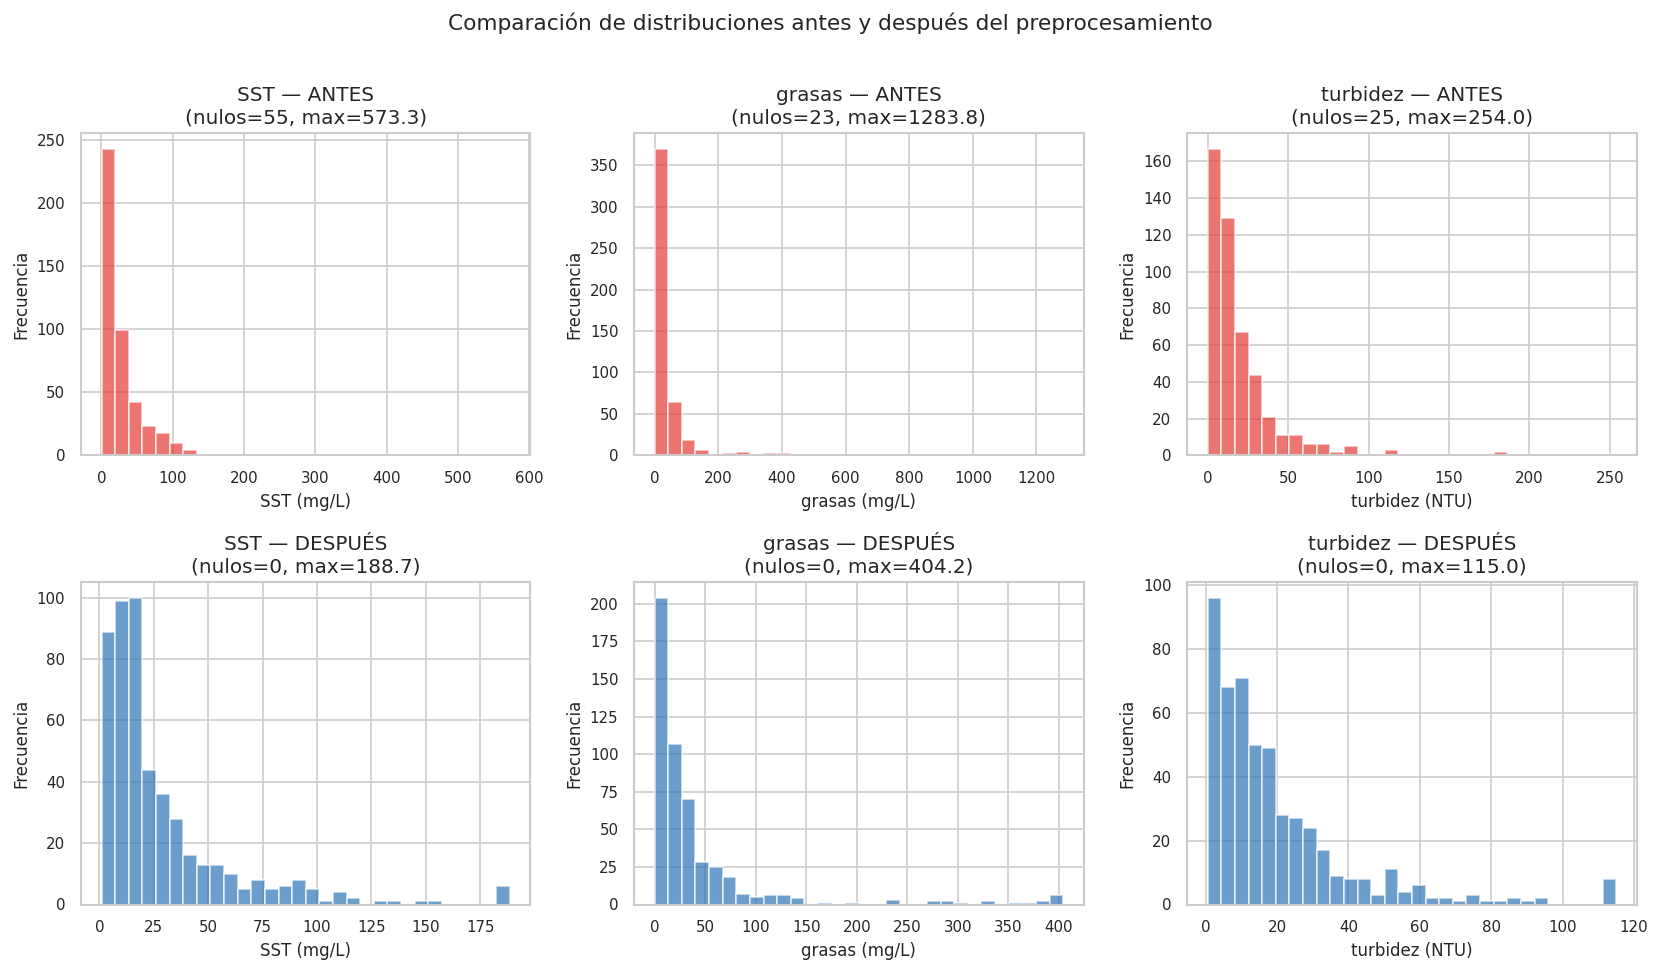


  Figura 5 guardada: fig5_comparacion_preprocesamiento.png


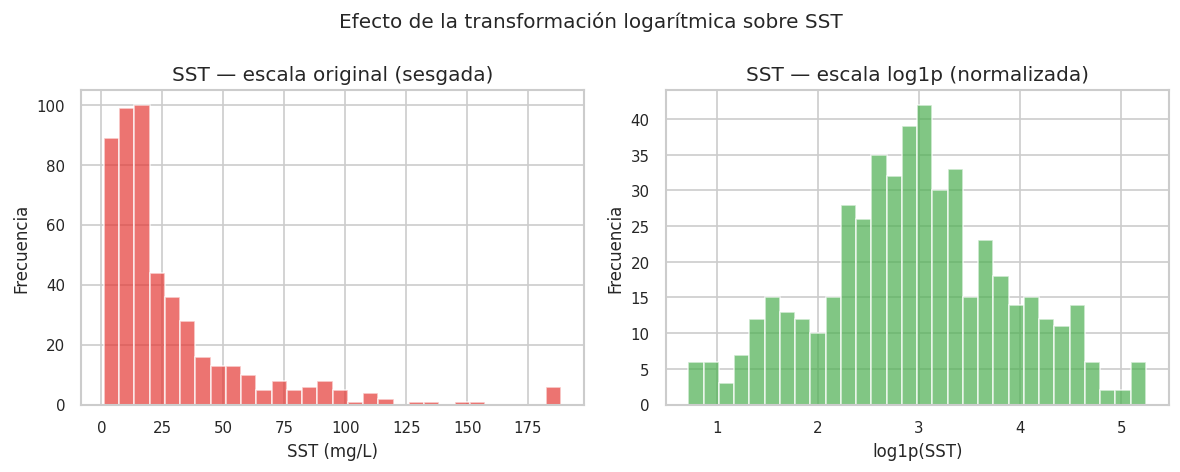

  Figura 6 guardada: fig6_transformacion_log.png

DATASET LIMPIO — RESUMEN FINAL
  Filas:    502
  Columnas: 23
  Nulos restantes: 0

  Variables de entrada disponibles para modelado:
    - año
    - mes
    - facilidad_target_enc
    - SST
    - grasas
    - turbidez
    - SST_log
    - grasas_log
    - turbidez_log
    - grasas_flag_NR
    - grasas_flag_ND
    - turbidez_flag_NR
    - tipo_CPI
    - tipo_CPL
    - tipo_CPN
    - tipo_Celda
    - tipo_Filtro
    - tipo_Tanque
    - Calidad_num

  Dataset exportado: /content/drive/MyDrive/TFM/datos_limpios.csv

SECCIÓN 2 COMPLETADA
Continuar con Sección 3: Preparación para modelado


In [ ]:
# =============================================================================
# SECCIÓN 2: PREPROCESAMIENTO DE DATOS
# =============================================================================
# Este script aplica el pipeline completo de preprocesamiento al dataset crudo.
# Entrada:  template_modelo_filtros__SST_GYA_TURBIDEZ.xlsx (archivo original)
# Salida:   datos_limpios.csv (dataset tratado, listo para modelado)
#
# Pasos aplicados (metodología CRISP-DM - fase Data Preparation):
#   2.1  Carga del dataset original
#   2.2  Eliminación de columna sin variabilidad (estacion)
#   2.3  Descomposición de fecha en año y mes
#   2.4  Tratamiento de valores especiales NR y ND
#   2.5  Imputación de valores faltantes
#   2.6  Control de outliers (Winsorizing p1-p99)
#   2.7  Agrupación y encoding de variable categórica Facilidad
#   2.8  Encoding de variable objetivo
#   2.9  Transformación logarítmica
#   2.10 Visualización comparativa antes/después
#   2.11 Exportación del dataset limpio
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

from google.colab import drive
drive.mount('/content/drive')

CARPETA    = '/content/drive/MyDrive/TFM/'
RUTA_DATOS = CARPETA + 'template_modelo_filtros _SST_GYA_TURBIDEZ.xlsx'
RUTA_SALIDA = CARPETA + 'datos_limpios.csv'

# =============================================================================
# 2.1 CARGA DEL DATASET ORIGINAL
# =============================================================================
df = pd.read_excel(RUTA_DATOS)
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

print("=" * 60)
print("SECCIÓN 2: PREPROCESAMIENTO DE DATOS")
print("=" * 60)
print(f"  Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")

# =============================================================================
# 2.2 ELIMINACIÓN DE COLUMNA SIN VARIABILIDAD
# =============================================================================
# La columna 'estacion' contiene un único valor ('Estación 1') en los 502
# registros. Una variable constante tiene varianza = 0 y no aporta capacidad
# discriminativa a los modelos. Se elimina para evitar ruido innecesario.

df.drop(columns=['estacion'], inplace=True)
print("\n  [2.2] Columna 'estacion' eliminada (varianza = 0, valor único).")

# =============================================================================
# 2.3 DESCOMPOSICIÓN DE FECHA
# =============================================================================
# La fecha cruda no es directamente utilizable como feature numérico. Se
# extraen año y mes como variables enteras que permiten capturar tendencias
# temporales y posibles efectos estacionales en el comportamiento del proceso.

df['año'] = df['fecha'].dt.year
df['mes']  = df['fecha'].dt.month
print("  [2.3] Variables 'año' y 'mes' extraídas de la columna fecha.")

# =============================================================================
# 2.4 TRATAMIENTO DE VALORES ESPECIALES NR Y ND
# =============================================================================
# Se distinguen dos tipos de valores especiales con semántica diferente:
#
#   NR (No Reportado): indica fallo en la medición o en el registro del dato.
#   Semánticamente equivale a un dato ausente → se convierte a NaN.
#
#   ND (No Detectado): indica que el valor está por debajo del límite de
#   detección del instrumento. No es un error; es una medición válida que
#   indica concentración cercana a cero → se convierte a 0.0.
#
# Adicionalmente se crean flags binarios que preservan la información sobre
# el origen del valor (fallo vs. límite de detección), ya que esta distinción
# puede ser relevante para el modelo.

# --- grasas ---
nr_grasas = (df['grasas'] == 'NR').sum()
nd_grasas = (df['grasas'] == 'ND').sum()
df['grasas_flag_NR'] = (df['grasas'] == 'NR').astype(int)
df['grasas_flag_ND'] = (df['grasas'] == 'ND').astype(int)
df['grasas'] = pd.to_numeric(
    df['grasas'].replace({'NR': np.nan, 'ND': 0.0}), errors='coerce'
)

# --- turbidez ---
nr_turb = (df['turbidez'] == 'NR').sum()
df['turbidez_flag_NR'] = (df['turbidez'] == 'NR').astype(int)
df['turbidez'] = pd.to_numeric(
    df['turbidez'].replace({'NR': np.nan}), errors='coerce'
)

print(f"  [2.4] Valores especiales tratados:")
print(f"        grasas  → NR({nr_grasas})→NaN | ND({nd_grasas})→0.0 | Flags creados.")
print(f"        turbidez → NR({nr_turb})→NaN | Flag creado.")

# =============================================================================
# 2.5 IMPUTACIÓN DE VALORES FALTANTES
# =============================================================================
# Estrategia: mediana por grupos homogéneos (Facilidad + Calidad).
# Se usa la mediana en lugar de la media porque las tres variables presentan
# distribuciones sesgadas con valores extremos que distorsionarían la media.
# Si un grupo no tiene suficientes datos para calcular la mediana, se aplica
# como fallback la mediana global por clase de Calidad.

nulos_antes = {col: df[col].isna().sum() for col in ['SST', 'grasas', 'turbidez']}

for col in ['SST', 'grasas', 'turbidez']:
    mediana_grupo   = df.groupby(['Facilidad', 'Calidad'])[col].transform('median')
    mediana_calidad = df.groupby('Calidad')[col].transform('median')
    df[col] = df[col].fillna(mediana_grupo).fillna(mediana_calidad)

nulos_despues = {col: df[col].isna().sum() for col in ['SST', 'grasas', 'turbidez']}

print(f"\n  [2.5] Imputación de nulos (mediana por Facilidad+Calidad):")
for col in ['SST', 'grasas', 'turbidez']:
    print(f"        {col}: {nulos_antes[col]} nulos → {nulos_despues[col]} nulos restantes.")

# =============================================================================
# 2.6 CONTROL DE OUTLIERS — WINSORIZING P1-P99
# =============================================================================
# Las tres variables presentan valores extremos con alta dispersión (std > media
# en grasas y SST). Se aplica Winsorizing al percentil 1-99: los valores por
# debajo del percentil 1 se reemplazan por ese percentil, y los valores por
# encima del percentil 99 se reemplazan por ese percentil.
#
# No se eliminan filas porque en agua de producción los valores extremos pueden
# corresponder a condiciones operativas reales. Winsorizing los conserva pero
# limita su influencia sobre los modelos sensibles a escala.

limites = {}
for col in ['SST', 'grasas', 'turbidez']:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    n_out = ((df[col] < p01) | (df[col] > p99)).sum()
    df[col] = df[col].clip(lower=p01, upper=p99)
    limites[col] = (p01, p99)
    print(f"  [2.6] Winsorizing '{col}': {n_out} valores recortados "
          f"→ rango [{p01:.2f}, {p99:.2f}]")

# =============================================================================
# 2.7 AGRUPACIÓN Y ENCODING DE VARIABLE CATEGÓRICA 'Facilidad'
# =============================================================================
# La variable 'Facilidad' tiene 58 categorías únicas. Aplicar One-Hot Encoding
# directamente generaría 58 columnas dummy sobre 502 registros, lo que produce
# matrices dispersas y riesgo de overfitting.
#
# Solución: se agrupa por tipo de equipo (7 categorías) reduciendo la
# cardinalidad a un nivel manejable. Adicionalmente se calcula un Target
# Encoding (proporción de registros Mala por facilidad) como feature continuo
# útil para modelos de árbol.

def clasificar_facilidad(nombre):
    n = str(nombre).upper()
    if 'FILTRO'  in n: return 'Filtro'
    if 'CELDA'   in n: return 'Celda'
    if 'CPI'     in n: return 'CPI'
    if 'TANQUE'  in n: return 'Tanque'
    if 'CPL'     in n: return 'CPL'
    if 'CPN'     in n or 'CP ' in n or 'CPS' in n: return 'CPN'
    # Entrada y Salida se separan deliberadamente: representan puntos
    # operativos distintos (agua cruda vs. efluente tratado) y deben
    # ser distinguibles por el modelo.
    if 'ENTRADA' in n: return 'Entrada'
    if 'SALIDA'  in n: return 'Salida'
    if 'STAP'    in n: return 'STAP'
    return 'Otro'

df['tipo_facilidad'] = df['Facilidad'].apply(clasificar_facilidad)

# Target encoding: proporción de Calidad=Mala por facilidad
target_map = df.groupby('Facilidad')['Calidad'].apply(
    lambda x: (x == 'Mala').mean()
).to_dict()
df['facilidad_target_enc'] = df['Facilidad'].map(target_map).round(4)

# One-Hot Encoding sobre tipo_facilidad (7 categorías)
ohe = pd.get_dummies(df['tipo_facilidad'], prefix='tipo').astype(int)
df  = pd.concat([df, ohe], axis=1)

print(f"\n  [2.7] Encoding de 'Facilidad':")
print(f"        58 categorías → 9 tipos: {sorted(df['tipo_facilidad'].unique().tolist())}")
print(f"        Nota: Entrada y Salida STAP se mantienen separadas —")
print(f"        representan agua cruda vs. efluente tratado respectivamente.")
print(f"        One-Hot Encoding: {ohe.shape[1]} columnas creadas.")
print(f"        Target Encoding: columna 'facilidad_target_enc' creada.")

# =============================================================================
# 2.8 ENCODING DE VARIABLE OBJETIVO
# =============================================================================
# Se crea una versión numérica de la variable objetivo para los modelos:
# Mala = 1 (clase positiva, de interés para detección de anomalías)
# Buena = 0 (clase negativa)

df['Calidad_num'] = (df['Calidad'] == 'Mala').astype(int)
print(f"\n  [2.8] Variable objetivo codificada: Mala=1, Buena=0.")

# =============================================================================
# 2.9 TRANSFORMACIÓN LOGARÍTMICA
# =============================================================================
# SST, grasas y turbidez tienen distribuciones fuertemente sesgadas a la
# derecha. La transformación log1p (log(1+x)) normaliza la distribución y
# estabiliza la varianza, lo que mejora el desempeño de modelos lineales y
# redes neuronales. log1p se usa en lugar de log para manejar valores = 0.

for col in ['SST', 'grasas', 'turbidez']:
    df[f'{col}_log'] = np.log1p(df[col])

print(f"  [2.9] Transformación log1p aplicada: columnas SST_log, grasas_log, turbidez_log.")

# =============================================================================
# 2.10 VISUALIZACIÓN COMPARATIVA ANTES / DESPUÉS
# =============================================================================

# Recargar versión cruda para comparar distribuciones
df_raw = pd.read_excel(RUTA_DATOS)
for col in ['grasas', 'turbidez']:
    df_raw[col] = pd.to_numeric(
        df_raw[col].replace({'NR': np.nan, 'ND': np.nan}), errors='coerce'
    )

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
variables = ['SST', 'grasas', 'turbidez']
unidades  = ['mg/L', 'mg/L', 'NTU']

for j, (var, unidad) in enumerate(zip(variables, unidades)):
    # Fila superior: antes del tratamiento
    ax_ant = axes[0, j]
    datos_ant = df_raw[var].dropna()
    ax_ant.hist(datos_ant, bins=30, color='#E53935', alpha=0.7, edgecolor='white')
    ax_ant.set_title(f'{var} — ANTES\n(nulos={df_raw[var].isna().sum()}, '
                     f'max={datos_ant.max():.1f})')
    ax_ant.set_xlabel(f'{var} ({unidad})')
    ax_ant.set_ylabel('Frecuencia')

    # Fila inferior: después del tratamiento
    ax_des = axes[1, j]
    ax_des.hist(df[var], bins=30, color='#2E75B6', alpha=0.7, edgecolor='white')
    ax_des.set_title(f'{var} — DESPUÉS\n(nulos={df[var].isna().sum()}, '
                     f'max={df[var].max():.1f})')
    ax_des.set_xlabel(f'{var} ({unidad})')
    ax_des.set_ylabel('Frecuencia')

plt.suptitle('Comparación de distribuciones antes y después del preprocesamiento',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig5_comparacion_preprocesamiento.png', bbox_inches='tight')
plt.show()
print("\n  Figura 5 guardada: fig5_comparacion_preprocesamiento.png")

# Figura adicional: distribución log vs. original para SST
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df['SST'],     bins=30, color='#E53935', alpha=0.7, edgecolor='white')
axes[0].set_title('SST — escala original (sesgada)')
axes[0].set_xlabel('SST (mg/L)')
axes[1].hist(df['SST_log'], bins=30, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1].set_title('SST — escala log1p (normalizada)')
axes[1].set_xlabel('log1p(SST)')
for ax in axes:
    ax.set_ylabel('Frecuencia')
plt.suptitle('Efecto de la transformación logarítmica sobre SST', fontsize=12)
plt.tight_layout()
plt.savefig('fig6_transformacion_log.png', bbox_inches='tight')
plt.show()
print("  Figura 6 guardada: fig6_transformacion_log.png")

# =============================================================================
# 2.11 RESUMEN DEL DATASET LIMPIO Y EXPORTACIÓN
# =============================================================================

# Selección de columnas finales para el dataset de salida
cols_salida = [
    'fecha', 'año', 'mes',
    'Facilidad', 'tipo_facilidad', 'facilidad_target_enc',
    'SST', 'grasas', 'turbidez',
    'SST_log', 'grasas_log', 'turbidez_log',
    'grasas_flag_NR', 'grasas_flag_ND', 'turbidez_flag_NR',
    'tipo_CPI', 'tipo_CPL', 'tipo_CPN', 'tipo_Celda',
    'tipo_Filtro', 'tipo_STAP', 'tipo_Tanque',
    'Calidad', 'Calidad_num'
]

# Verificar que todas las columnas OHE existen (depende de los datos)
cols_salida = [c for c in cols_salida if c in df.columns]
df_limpio = df[cols_salida].copy()

print("\n" + "=" * 60)
print("DATASET LIMPIO — RESUMEN FINAL")
print("=" * 60)
print(f"  Filas:    {df_limpio.shape[0]}")
print(f"  Columnas: {df_limpio.shape[1]}")
print(f"  Nulos restantes: {df_limpio.isnull().sum().sum()}")
print(f"\n  Variables de entrada disponibles para modelado:")
features_modelo = [c for c in cols_salida if c not in ['fecha', 'Facilidad',
                                                         'tipo_facilidad', 'Calidad']]
for f in features_modelo:
    print(f"    - {f}")

df_limpio.to_csv(RUTA_SALIDA, index=False)
print(f"\n  Dataset exportado: {RUTA_SALIDA}")

print("\n" + "=" * 60)
print("SECCIÓN 2 COMPLETADA")
print("Continuar con Sección 3: Preparación para modelado")
print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SECCIÓN 3: PREPARACIÓN PARA EL MODELADO
  Dataset cargado: 502 filas x 23 columnas
  Distribución de clases:
    Mala  (1): 459 registros
    Buena (0): 43 registros

ANÁLISIS: SALIDA STAP — REGISTROS CRÍTICOS
  Total registros Salida STAP: 22
    Calidad Mala  (incumplimiento): 21
    Calidad Buena (cumplimiento):   1

  Estadísticas de Salida STAP con calidad MALA:
          SST   grasas  turbidez
count  21.000   21.000    21.000
mean   23.745   44.215    11.975
std    19.194   86.445    18.148
min     3.500    0.000     0.960
25%    12.000    7.500     2.490
50%    18.460   18.325     6.470
75%    29.300   41.820    10.800
max    85.333  404.224    81.400


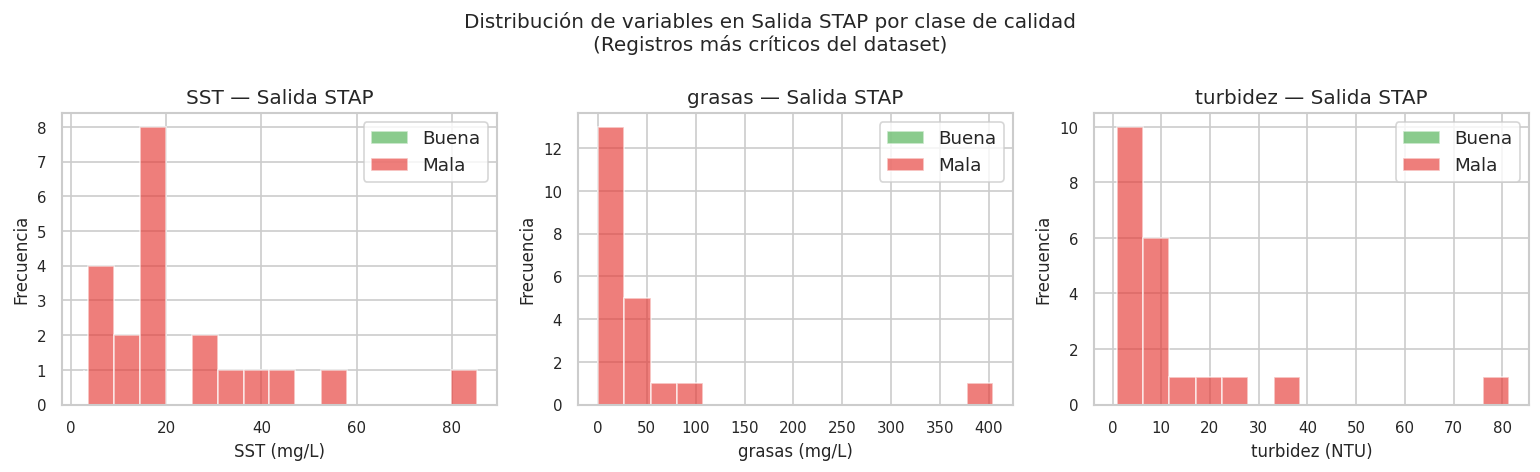


  Figura 7 guardada: fig7_salida_stap_criticos.png

SELECCIÓN DE FEATURES
  Total features seleccionados: 18
  Features numéricos (9): ['SST', 'grasas', 'turbidez', 'SST_log', 'grasas_log', 'turbidez_log', 'facilidad_target_enc', 'año', 'mes']
  Features binarios  (9): ['grasas_flag_NR', 'grasas_flag_ND', 'turbidez_flag_NR', 'tipo_CPI', 'tipo_CPL', 'tipo_CPN', 'tipo_Celda', 'tipo_Filtro', 'tipo_Tanque']
  Variable objetivo: Calidad_num

DIVISIÓN TRAIN / TEST (80% / 20%) — ESTRATIFICADA
  Conjunto de entrenamiento: 401 registros
    Mala  (1): 367 (91.5%)
    Buena (0): 34 (8.5%)

  Conjunto de prueba: 101 registros
    Mala  (1): 92 (91.1%)
    Buena (0): 9 (8.9%)

  La estratificación preservó la proporción de clases en ambos conjuntos.

ESCALADO DE VARIABLES NUMÉRICAS (StandardScaler)
  Scaler ajustado sobre 401 registros de entrenamiento.
  Aplicado al conjunto de prueba sin reajuste (evita data leakage).
  Parámetros del scaler guardados en: /content/drive/MyDrive/TFM/scaler_param

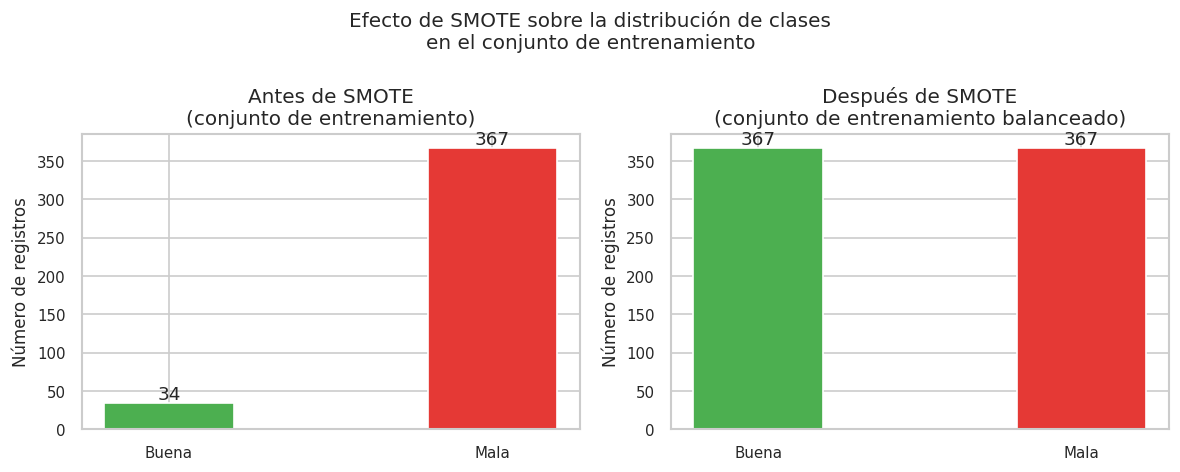


  Figura 8 guardada: fig8_efecto_smote.png

ARCHIVOS EXPORTADOS
  /content/drive/MyDrive/TFM/X_train.csv       → 401 registros, 18 features
  /content/drive/MyDrive/TFM/X_test.csv        → 101 registros, 18 features
  /content/drive/MyDrive/TFM/y_train.csv       → variable objetivo (entrenamiento)
  /content/drive/MyDrive/TFM/y_test.csv        → variable objetivo (prueba)
  /content/drive/MyDrive/TFM/X_train_smote.csv → 734 registros balanceados (SMOTE)
  /content/drive/MyDrive/TFM/y_train_smote.csv → variable objetivo balanceada (SMOTE)
  /content/drive/MyDrive/TFM/scaler_params.csv → parámetros del StandardScaler

SECCIÓN 3 COMPLETADA
Continuar con Sección 4: Entrenamiento de modelos


In [ ]:
# =============================================================================
# SECCIÓN 3: PREPARACIÓN PARA EL MODELADO
# =============================================================================
# Este script toma el dataset limpio producido en la Sección 2 y lo prepara
# para el entrenamiento de los modelos de machine learning.
#
# Entrada:  datos_limpios.csv
# Salidas:  X_train.csv, X_test.csv, y_train.csv, y_test.csv
#           X_train_smote.csv, y_train_smote.csv (conjunto balanceado)
#
# Pasos aplicados:
#   3.1  Carga del dataset limpio
#   3.2  Análisis de registros Salida STAP con calidad Mala
#   3.3  Selección de features para el modelo
#   3.4  División estratificada train/test (80/20)
#   3.5  Escalado de variables numéricas
#   3.6  Aplicación de SMOTE sobre el conjunto de entrenamiento
#   3.7  Verificación y exportación
# =============================================================================

# Instalación de librerías requeridas (descomentar en Google Colab):
# !pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

from google.colab import drive
drive.mount('/content/drive')

CARPETA      = '/content/drive/MyDrive/TFM/'
RUTA_ENTRADA = CARPETA + 'datos_limpios.csv'
RUTA_X_TRAIN      = CARPETA + 'X_train.csv'
RUTA_X_TEST       = CARPETA + 'X_test.csv'
RUTA_Y_TRAIN      = CARPETA + 'y_train.csv'
RUTA_Y_TEST       = CARPETA + 'y_test.csv'
RUTA_X_TRAIN_SMOTE = CARPETA + 'X_train_smote.csv'
RUTA_Y_TRAIN_SMOTE = CARPETA + 'y_train_smote.csv'
RUTA_SCALER_PARAMS = CARPETA + 'scaler_params.csv'

# =============================================================================
# 3.1 CARGA DEL DATASET LIMPIO
# =============================================================================
df = pd.read_csv(RUTA_ENTRADA, parse_dates=['fecha'])

print("=" * 60)
print("SECCIÓN 3: PREPARACIÓN PARA EL MODELADO")
print("=" * 60)
print(f"  Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"  Distribución de clases:")
print(f"    Mala  (1): {(df['Calidad_num']==1).sum()} registros")
print(f"    Buena (0): {(df['Calidad_num']==0).sum()} registros")

# =============================================================================
# 3.2 ANÁLISIS DE REGISTROS SALIDA STAP CON CALIDAD MALA
# =============================================================================
# Los registros de 'Salida STAP' con calidad 'Mala' representan los eventos
# más críticos del dataset: son los casos en que el efluente final del sistema
# de tratamiento no cumplió con las especificaciones de reinyección. Estos
# registros son el objetivo principal de detección del modelo.

salida_mala = df[(df['tipo_facilidad'] == 'Salida') & (df['Calidad_num'] == 1)]
salida_buena = df[(df['tipo_facilidad'] == 'Salida') & (df['Calidad_num'] == 0)]

print("\n" + "=" * 60)
print("ANÁLISIS: SALIDA STAP — REGISTROS CRÍTICOS")
print("=" * 60)
print(f"  Total registros Salida STAP: {len(salida_mala) + len(salida_buena)}")
print(f"    Calidad Mala  (incumplimiento): {len(salida_mala)}")
print(f"    Calidad Buena (cumplimiento):   {len(salida_buena)}")

if len(salida_mala) > 0:
    print(f"\n  Estadísticas de Salida STAP con calidad MALA:")
    print(salida_mala[['SST', 'grasas', 'turbidez']].describe().round(3).to_string())

# Figura 7: Comparación de variables en Salida STAP por clase
if len(salida_mala) + len(salida_buena) > 0:
    salida_df = df[df['tipo_facilidad'] == 'Salida'].copy()
    salida_df['Clase'] = salida_df['Calidad_num'].map({1: 'Mala', 0: 'Buena'})

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    variables = ['SST', 'grasas', 'turbidez']
    unidades  = ['mg/L', 'mg/L', 'NTU']
    colores   = {'Buena': '#4CAF50', 'Mala': '#E53935'}

    for ax, var, unidad in zip(axes, variables, unidades):
        for clase, color in colores.items():
            datos = salida_df[salida_df['Clase'] == clase][var]
            if len(datos) > 0:
                ax.hist(datos, bins=15, alpha=0.65, color=color,
                        label=clase, edgecolor='white')
        ax.set_title(f'{var} — Salida STAP')
        ax.set_xlabel(f'{var} ({unidad})')
        ax.set_ylabel('Frecuencia')
        ax.legend()

    plt.suptitle('Distribución de variables en Salida STAP por clase de calidad\n'
                 '(Registros más críticos del dataset)', fontsize=12)
    plt.tight_layout()
    plt.savefig('fig7_salida_stap_criticos.png', bbox_inches='tight')
    plt.show()
    print("\n  Figura 7 guardada: fig7_salida_stap_criticos.png")

# =============================================================================
# 3.3 SELECCIÓN DE FEATURES PARA EL MODELO
# =============================================================================
# Se definen dos conjuntos de features:
#
# - features_num: variables numéricas continuas que requieren escalado.
#   Se usan las versiones log1p de SST, grasas y turbidez en lugar de las
#   originales para los modelos sensibles a escala (regresión logística).
#   Para modelos de árbol (Random Forest, XGBoost) se incluyen ambas versiones.
#
# - features_bin: variables binarias (flags y One-Hot Encoding) que no
#   requieren escalado porque ya están en el rango [0, 1].
#
# La variable objetivo es Calidad_num (1=Mala, 0=Buena).
# Las columnas fecha, Facilidad, tipo_facilidad y Calidad (texto) se excluyen
# porque son identificadores o versiones redundantes de otras variables.

features_num = [
    'SST', 'grasas', 'turbidez',
    'SST_log', 'grasas_log', 'turbidez_log',
    'facilidad_target_enc',
    'año', 'mes'
]

features_bin = [
    'grasas_flag_NR', 'grasas_flag_ND', 'turbidez_flag_NR',
    'tipo_CPI', 'tipo_CPL', 'tipo_CPN', 'tipo_Celda',
    'tipo_Filtro', 'tipo_STAP', 'tipo_Tanque',
    'tipo_Entrada', 'tipo_Salida'
]

# Conservar solo las columnas OHE que existan en el dataset
# (depende de los tipos presentes en los datos)
features_bin = [f for f in features_bin if f in df.columns]
features_all = features_num + features_bin

TARGET = 'Calidad_num'

X = df[features_all].copy()
y = df[TARGET].copy()

print("\n" + "=" * 60)
print("SELECCIÓN DE FEATURES")
print("=" * 60)
print(f"  Total features seleccionados: {len(features_all)}")
print(f"  Features numéricos ({len(features_num)}): {features_num}")
print(f"  Features binarios  ({len(features_bin)}): {features_bin}")
print(f"  Variable objetivo: {TARGET}")

# =============================================================================
# 3.4 DIVISIÓN ESTRATIFICADA TRAIN / TEST (80 / 20)
# =============================================================================
# Se aplica división estratificada para garantizar que la proporción de clases
# (Mala/Buena) se preserve en ambos conjuntos. Esto es especialmente importante
# dado el desbalanceo severo del dataset (10.7:1).
# random_state=42 asegura reproducibilidad del experimento.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("DIVISIÓN TRAIN / TEST (80% / 20%) — ESTRATIFICADA")
print("=" * 60)
print(f"  Conjunto de entrenamiento: {X_train.shape[0]} registros")
print(f"    Mala  (1): {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"    Buena (0): {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"\n  Conjunto de prueba: {X_test.shape[0]} registros")
print(f"    Mala  (1): {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"    Buena (0): {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"\n  La estratificación preservó la proporción de clases en ambos conjuntos.")

# =============================================================================
# 3.5 ESCALADO DE VARIABLES NUMÉRICAS
# =============================================================================
# Se aplica StandardScaler (media=0, std=1) sobre las variables numéricas.
# Importante: el scaler se ajusta SOLO sobre el conjunto de entrenamiento
# y luego se aplica al conjunto de prueba. Ajustarlo sobre todo el dataset
# introduciría data leakage (el modelo conocería información del futuro).

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[features_num] = scaler.fit_transform(X_train[features_num])
X_test_scaled[features_num]  = scaler.transform(X_test[features_num])

# Guardar parámetros del scaler para reproducibilidad
scaler_params = pd.DataFrame({
    'feature': features_num,
    'media':   scaler.mean_,
    'std':     scaler.scale_
})
scaler_params.to_csv(RUTA_SCALER_PARAMS, index=False)

print("\n" + "=" * 60)
print("ESCALADO DE VARIABLES NUMÉRICAS (StandardScaler)")
print("=" * 60)
print(f"  Scaler ajustado sobre {X_train.shape[0]} registros de entrenamiento.")
print(f"  Aplicado al conjunto de prueba sin reajuste (evita data leakage).")
print(f"  Parámetros del scaler guardados en: {RUTA_SCALER_PARAMS}")

# =============================================================================
# 3.6 APLICACIÓN DE SMOTE SOBRE EL CONJUNTO DE ENTRENAMIENTO
# =============================================================================
# SMOTE (Synthetic Minority Oversampling Technique) genera registros sintéticos
# de la clase minoritaria (Buena=0) interpolando entre registros reales vecinos
# en el espacio de features. Se aplica ÚNICAMENTE sobre el conjunto de
# entrenamiento para evitar que información sintética contamine la evaluación.
#
# k_neighbors=5 es el valor estándar de la literatura. random_state=42
# garantiza reproducibilidad.

smote = SMOTE(k_neighbors=5, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\n" + "=" * 60)
print("BALANCEO DE CLASES — SMOTE")
print("=" * 60)
print(f"  Antes de SMOTE (entrenamiento):")
print(f"    Mala  (1): {y_train.sum()}")
print(f"    Buena (0): {(y_train==0).sum()}")
print(f"\n  Después de SMOTE (entrenamiento):")
print(f"    Mala  (1): {(y_train_sm==1).sum()}")
print(f"    Buena (0): {(y_train_sm==0).sum()}")
print(f"    Total:     {len(y_train_sm)} registros")
print(f"\n  Registros sintéticos generados: {len(y_train_sm) - len(y_train)}")
print(f"  Ratio Mala/Buena después de SMOTE: 1:1 (balanceo completo)")
print(f"\n  NOTA: SMOTE aplicado solo al conjunto de entrenamiento.")
print(f"  El conjunto de prueba conserva la distribución original (no balanceada)")
print(f"  para que la evaluación refleje condiciones reales de operación.")

# =============================================================================
# 3.7 VISUALIZACIÓN: EFECTO DEL SMOTE
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colores = {1: '#E53935', 0: '#4CAF50'}
etiquetas = {1: 'Mala', 0: 'Buena'}

# Antes de SMOTE
conteo_antes = y_train.value_counts().sort_index()
axes[0].bar([etiquetas[i] for i in conteo_antes.index],
            conteo_antes.values,
            color=[colores[i] for i in conteo_antes.index],
            edgecolor='white', width=0.4)
axes[0].set_title('Antes de SMOTE\n(conjunto de entrenamiento)')
axes[0].set_ylabel('Número de registros')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Después de SMOTE
conteo_despues = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar([etiquetas[i] for i in conteo_despues.index],
            conteo_despues.values,
            color=[colores[i] for i in conteo_despues.index],
            edgecolor='white', width=0.4)
axes[1].set_title('Después de SMOTE\n(conjunto de entrenamiento balanceado)')
axes[1].set_ylabel('Número de registros')
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.suptitle('Efecto de SMOTE sobre la distribución de clases\n'
             'en el conjunto de entrenamiento', fontsize=12)
plt.tight_layout()
plt.savefig('fig8_efecto_smote.png', bbox_inches='tight')
plt.show()
print("\n  Figura 8 guardada: fig8_efecto_smote.png")

# =============================================================================
# 3.8 EXPORTACIÓN DE CONJUNTOS
# =============================================================================
# Se exportan los cuatro conjuntos base (train/test sin SMOTE, escalados)
# y el conjunto de entrenamiento balanceado con SMOTE.
# La Sección 4 cargará X_train_smote y y_train_smote para entrenar los modelos,
# y X_test / y_test para evaluarlos.

X_train_scaled.to_csv(RUTA_X_TRAIN,       index=False)
X_test_scaled.to_csv(RUTA_X_TEST,         index=False)
y_train.to_csv(RUTA_Y_TRAIN,              index=False)
y_test.to_csv(RUTA_Y_TEST,                index=False)

pd.DataFrame(X_train_sm, columns=features_all).to_csv(RUTA_X_TRAIN_SMOTE, index=False)
pd.Series(y_train_sm, name=TARGET).to_csv(RUTA_Y_TRAIN_SMOTE,             index=False)

print("\n" + "=" * 60)
print("ARCHIVOS EXPORTADOS")
print("=" * 60)
print(f"  {RUTA_X_TRAIN}       → {X_train_scaled.shape[0]} registros, {X_train_scaled.shape[1]} features")
print(f"  {RUTA_X_TEST}        → {X_test_scaled.shape[0]} registros, {X_test_scaled.shape[1]} features")
print(f"  {RUTA_Y_TRAIN}       → variable objetivo (entrenamiento)")
print(f"  {RUTA_Y_TEST}        → variable objetivo (prueba)")
print(f"  {RUTA_X_TRAIN_SMOTE} → {X_train_sm.shape[0]} registros balanceados (SMOTE)")
print(f"  {RUTA_Y_TRAIN_SMOTE} → variable objetivo balanceada (SMOTE)")
print(f"  {RUTA_SCALER_PARAMS} → parámetros del StandardScaler")

print("\n" + "=" * 60)
print("SECCIÓN 3 COMPLETADA")
print("Continuar con Sección 4: Entrenamiento de modelos")
print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SECCIÓN 4: ENTRENAMIENTO DE MODELOS
  Conjunto de entrenamiento (SMOTE): 734 registros
    Mala  (1): 367 | Buena (0): 367
  Conjunto de prueba (original):     101 registros
    Mala  (1): 92 | Buena (0): 9

  Features utilizados: 18

VALIDACIÓN CRUZADA ESTRATIFICADA (5 folds — F1 ponderado)

  Regresión Logística:
    F1 por fold: [np.float64(0.9728), np.float64(0.9728), np.float64(0.9864), np.float64(0.9796), np.float64(0.9863)]
    F1 media:    0.9796 ± 0.0061

  Random Forest:
    F1 por fold: [np.float64(0.9932), np.float64(0.9932), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
    F1 media:    0.9973 ± 0.0033

  XGBoost:
    F1 por fold: [np.float64(0.9932), np.float64(0.9932), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
    F1 media:    0.9973 ± 0.0033

ENTRENAMIENTO FINAL SOBRE CONJUNTO COMPLETO

  Regresión Logística: entrenado correctame

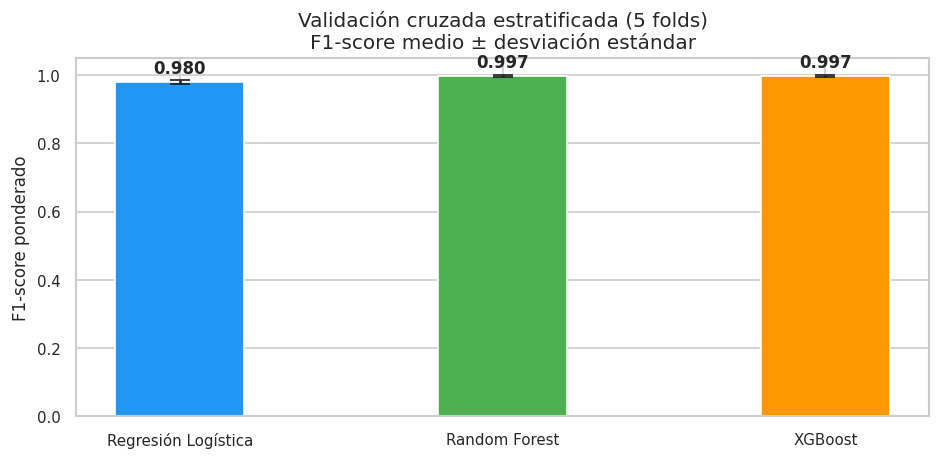


  Figura 9 guardada: fig9_validacion_cruzada.png


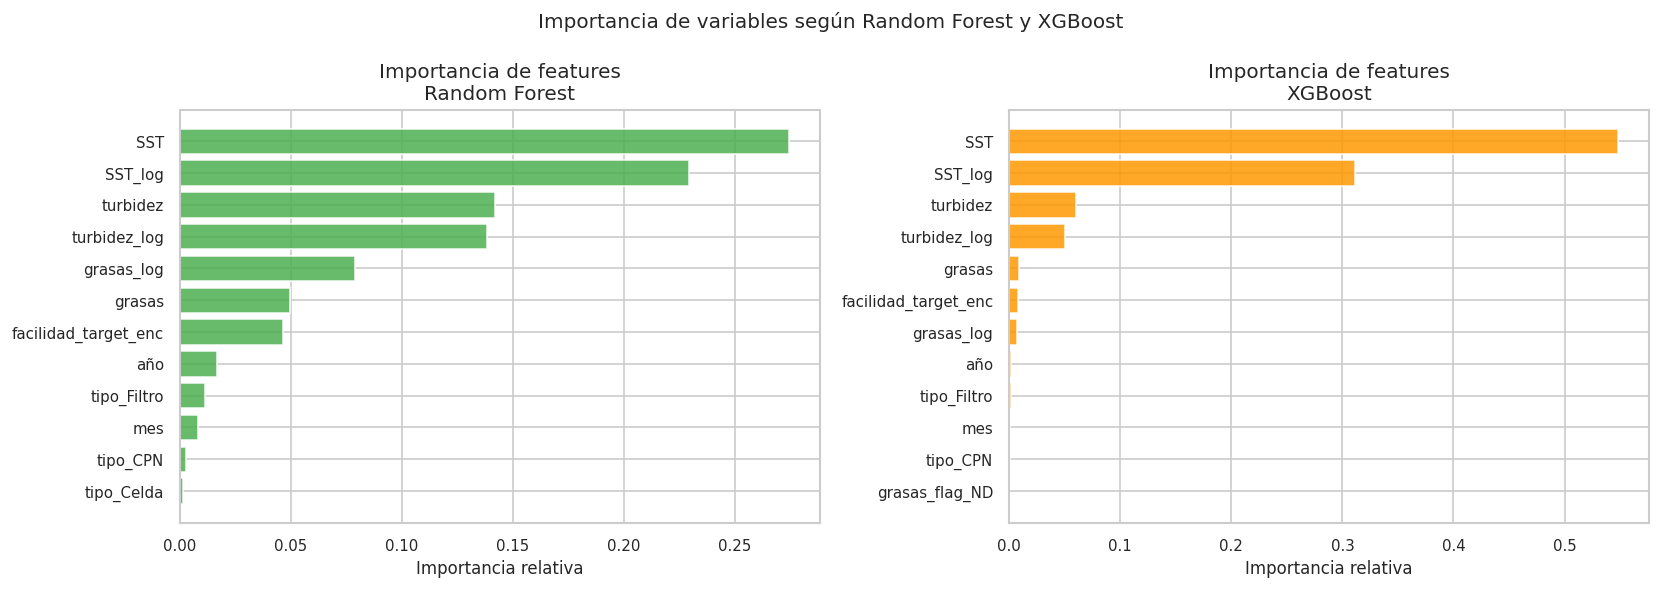

  Figura 10 guardada: fig10_importancia_features.png


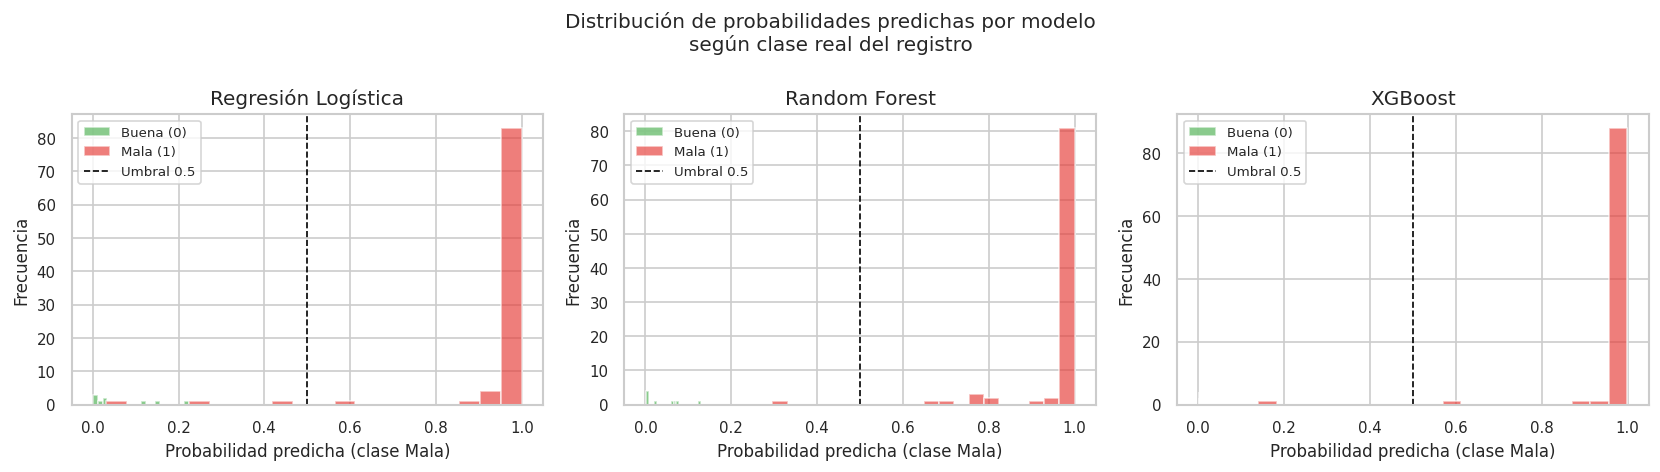

  Figura 11 guardada: fig11_probabilidades_predichas.png

ARCHIVOS EXPORTADOS
  /content/drive/MyDrive/TFM/predicciones_modelos.csv → predicciones de los 3 modelos sobre el conjunto de prueba
  /content/drive/MyDrive/TFM/importancia_features.csv  → importancia de features por modelo
  /content/drive/MyDrive/TFM/modelos_entrenados.pkl      → modelos entrenados (formato pickle)

SECCIÓN 4 COMPLETADA
Continuar con Sección 5: Evaluación y comparación de modelos


In [ ]:
# =============================================================================
# SECCIÓN 4: ENTRENAMIENTO DE MODELOS
# =============================================================================
# Este script entrena tres modelos de machine learning sobre el conjunto
# balanceado con SMOTE y genera las predicciones sobre el conjunto de prueba.
#
# Entradas: X_train_smote.csv, y_train_smote.csv (entrenamiento balanceado)
#           X_test.csv, y_test.csv               (prueba original)
# Salidas:  predicciones_modelos.csv             (predicciones de los tres modelos)
#           importancia_features.csv             (importancia de variables)
#
# Modelos entrenados:
#   4.1  Regresión Logística  — modelo base de referencia (baseline)
#   4.2  Random Forest        — ensemble de árboles de decisión
#   4.3  XGBoost              — gradient boosting optimizado
#
# Los tres modelos se comparan en la Sección 5 mediante métricas de evaluación.
# =============================================================================

# Instalación de librerías requeridas (descomentar en Google Colab):
# !pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

from google.colab import drive
drive.mount('/content/drive')

CARPETA            = '/content/drive/MyDrive/TFM/'
RUTA_X_TRAIN_SMOTE = CARPETA + 'X_train_smote.csv'
RUTA_Y_TRAIN_SMOTE = CARPETA + 'y_train_smote.csv'
RUTA_X_TEST        = CARPETA + 'X_test.csv'
RUTA_Y_TEST        = CARPETA + 'y_test.csv'
RUTA_PREDICCIONES  = CARPETA + 'predicciones_modelos.csv'
RUTA_IMPORTANCIA   = CARPETA + 'importancia_features.csv'
RUTA_MODELOS       = CARPETA + 'modelos_entrenados.pkl'

# =============================================================================
# 4.1 CARGA DE DATOS
# =============================================================================
X_train = pd.read_csv(RUTA_X_TRAIN_SMOTE)
y_train = pd.read_csv(RUTA_Y_TRAIN_SMOTE).squeeze()
X_test  = pd.read_csv(RUTA_X_TEST)
y_test  = pd.read_csv(RUTA_Y_TEST).squeeze()

print("=" * 60)
print("SECCIÓN 4: ENTRENAMIENTO DE MODELOS")
print("=" * 60)
print(f"  Conjunto de entrenamiento (SMOTE): {X_train.shape[0]} registros")
print(f"    Mala  (1): {(y_train==1).sum()} | Buena (0): {(y_train==0).sum()}")
print(f"  Conjunto de prueba (original):     {X_test.shape[0]} registros")
print(f"    Mala  (1): {(y_test==1).sum()} | Buena (0): {(y_test==0).sum()}")

features = list(X_train.columns)
print(f"\n  Features utilizados: {len(features)}")

# =============================================================================
# 4.2 DEFINICIÓN DE MODELOS
# =============================================================================
# Se entrenan tres modelos con complejidad creciente:
#
# Regresión Logística: modelo lineal que sirve como baseline. Su simplicidad
# permite interpretar directamente el peso de cada variable. Si los modelos
# más complejos no mejoran significativamente sobre este baseline, el modelo
# lineal sería preferible por su mayor interpretabilidad.
#
# Random Forest: ensemble de 300 árboles de decisión entrenados sobre
# subconjuntos aleatorios de datos y features. Robusto ante outliers y
# variables irrelevantes. Proporciona importancia de features nativa.
#
# XGBoost: gradient boosting que construye árboles secuencialmente corrigiendo
# los errores del árbol anterior. Generalmente produce el mejor desempeño
# predictivo en datasets tabulares de tamaño medio.
#
# En todos los modelos se aplica class_weight o scale_pos_weight como capa
# adicional de protección frente al desbalanceo, complementando el SMOTE.

modelos = {
    'Regresión Logística': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
}

# =============================================================================
# 4.3 VALIDACIÓN CRUZADA ESTRATIFICADA
# =============================================================================
# Antes de entrenar sobre todo el conjunto de entrenamiento, se aplica
# validación cruzada estratificada con 5 folds para estimar el desempeño
# esperado de cada modelo y detectar posible overfitting.
# La métrica usada es F1-score (ponderado), apropiada para clases desbalanceadas.

print("\n" + "=" * 60)
print("VALIDACIÓN CRUZADA ESTRATIFICADA (5 folds — F1 ponderado)")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = {}

for nombre, modelo in modelos.items():
    scores = cross_val_score(
        modelo, X_train, y_train,
        cv=cv, scoring='f1_weighted', n_jobs=-1
    )
    resultados_cv[nombre] = scores
    print(f"\n  {nombre}:")
    print(f"    F1 por fold: {[round(s, 4) for s in scores]}")
    print(f"    F1 media:    {scores.mean():.4f} ± {scores.std():.4f}")

# =============================================================================
# 4.4 ENTRENAMIENTO FINAL
# =============================================================================
# Se entrena cada modelo sobre la totalidad del conjunto de entrenamiento
# balanceado (SMOTE) para maximizar la información disponible.

print("\n" + "=" * 60)
print("ENTRENAMIENTO FINAL SOBRE CONJUNTO COMPLETO")
print("=" * 60)

modelos_entrenados = {}
predicciones       = pd.DataFrame({'y_real': y_test.values})

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    modelos_entrenados[nombre] = modelo

    y_pred      = modelo.predict(X_test)
    y_pred_prob = modelo.predict_proba(X_test)[:, 1]

    predicciones[f'pred_{nombre}']     = y_pred
    predicciones[f'prob_{nombre}']     = y_pred_prob.round(4)

    print(f"\n  {nombre}: entrenado correctamente.")
    print(f"    Predicciones Mala  (1): {y_pred.sum()}")
    print(f"    Predicciones Buena (0): {(y_pred==0).sum()}")

# =============================================================================
# 4.5 IMPORTANCIA DE FEATURES
# =============================================================================
# Random Forest y XGBoost proporcionan importancia de features nativa.
# Para Regresión Logística se usan los coeficientes absolutos como proxy
# de importancia relativa (válido dado que las variables están escaladas).

print("\n" + "=" * 60)
print("IMPORTANCIA DE FEATURES")
print("=" * 60)

importancias = pd.DataFrame({'feature': features})

# Random Forest
rf_imp = modelos_entrenados['Random Forest'].feature_importances_
importancias['importancia_RF'] = rf_imp.round(6)

# XGBoost
xgb_imp = modelos_entrenados['XGBoost'].feature_importances_
importancias['importancia_XGB'] = xgb_imp.round(6)

# Regresión Logística (coeficientes absolutos normalizados)
lr_coef = np.abs(modelos_entrenados['Regresión Logística'].coef_[0])
importancias['importancia_LR'] = (lr_coef / lr_coef.sum()).round(6)

# Importancia promedio entre los tres modelos
importancias['importancia_promedio'] = importancias[
    ['importancia_RF', 'importancia_XGB', 'importancia_LR']
].mean(axis=1).round(6)

importancias = importancias.sort_values('importancia_promedio', ascending=False)

print("\n  Top 10 features más importantes (promedio entre modelos):")
print(importancias[['feature', 'importancia_RF', 'importancia_XGB',
                     'importancia_LR', 'importancia_promedio']].head(10).to_string(index=False))

# =============================================================================
# 4.6 VISUALIZACIONES
# =============================================================================

# Figura 9: F1 de validación cruzada por modelo
fig, ax = plt.subplots(figsize=(8, 4))
nombres  = list(resultados_cv.keys())
medias   = [resultados_cv[n].mean() for n in nombres]
stds     = [resultados_cv[n].std()  for n in nombres]
colores  = ['#2196F3', '#4CAF50', '#FF9800']

bars = ax.bar(nombres, medias, yerr=stds, capsize=6,
              color=colores, edgecolor='white', width=0.4)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1-score ponderado')
ax.set_title('Validación cruzada estratificada (5 folds)\nF1-score medio ± desviación estándar')
for bar, media, std in zip(bars, medias, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.01,
            f'{media:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(CARPETA + 'fig9_validacion_cruzada.png', bbox_inches='tight')
plt.show()
print("\n  Figura 9 guardada: fig9_validacion_cruzada.png")

# Figura 10: Importancia de features (Top 12, Random Forest y XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_n = 12

for ax, col, titulo, color in zip(
    axes,
    ['importancia_RF', 'importancia_XGB'],
    ['Random Forest', 'XGBoost'],
    ['#4CAF50', '#FF9800']
):
    top = importancias.nlargest(top_n, col)
    ax.barh(top['feature'], top[col], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Importancia de features\n{titulo}')
    ax.set_xlabel('Importancia relativa')
    ax.invert_yaxis()

plt.suptitle('Importancia de variables según Random Forest y XGBoost', fontsize=12)
plt.tight_layout()
plt.savefig(CARPETA + 'fig10_importancia_features.png', bbox_inches='tight')
plt.show()
print("  Figura 10 guardada: fig10_importancia_features.png")

# Figura 11: Distribución de probabilidades predichas por modelo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
modelos_nombres = ['Regresión Logística', 'Random Forest', 'XGBoost']
colores_clase   = {0: '#4CAF50', 1: '#E53935'}

for ax, nombre in zip(axes, modelos_nombres):
    col_prob = f'prob_{nombre}'
    for clase, color in colores_clase.items():
        mask = predicciones['y_real'] == clase
        ax.hist(predicciones.loc[mask, col_prob], bins=20,
                alpha=0.65, color=color,
                label='Buena (0)' if clase == 0 else 'Mala (1)',
                edgecolor='white')
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, label='Umbral 0.5')
    ax.set_title(nombre)
    ax.set_xlabel('Probabilidad predicha (clase Mala)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de probabilidades predichas por modelo\n'
             'según clase real del registro', fontsize=12)
plt.tight_layout()
plt.savefig(CARPETA + 'fig11_probabilidades_predichas.png', bbox_inches='tight')
plt.show()
print("  Figura 11 guardada: fig11_probabilidades_predichas.png")

# =============================================================================
# 4.7 EXPORTACIÓN
# =============================================================================
predicciones.to_csv(RUTA_PREDICCIONES, index=False)
importancias.to_csv(RUTA_IMPORTANCIA,  index=False)

# Guardar modelos entrenados para uso en secciones posteriores
with open(RUTA_MODELOS, 'wb') as f:
    pickle.dump(modelos_entrenados, f)

print("\n" + "=" * 60)
print("ARCHIVOS EXPORTADOS")
print("=" * 60)
print(f"  {RUTA_PREDICCIONES} → predicciones de los 3 modelos sobre el conjunto de prueba")
print(f"  {RUTA_IMPORTANCIA}  → importancia de features por modelo")
print(f"  {RUTA_MODELOS}      → modelos entrenados (formato pickle)")

print("\n" + "=" * 60)
print("SECCIÓN 4 COMPLETADA")
print("Continuar con Sección 5: Evaluación y comparación de modelos")
print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SECCIÓN 5: EVALUACIÓN Y COMPARACIÓN DE MODELOS
  Conjunto de prueba: 101 registros
    Mala  (1): 92 | Buena (0): 9

MATRICES DE CONFUSIÓN

  Regresión Logística:
    TP=89 | TN=9 | FP=0 | FN=3
    Fallos críticos (FN, Mala no detectada): 3

  Random Forest:
    TP=91 | TN=9 | FP=0 | FN=1
    Fallos críticos (FN, Mala no detectada): 1

  XGBoost:
    TP=91 | TN=9 | FP=0 | FN=1
    Fallos críticos (FN, Mala no detectada): 1


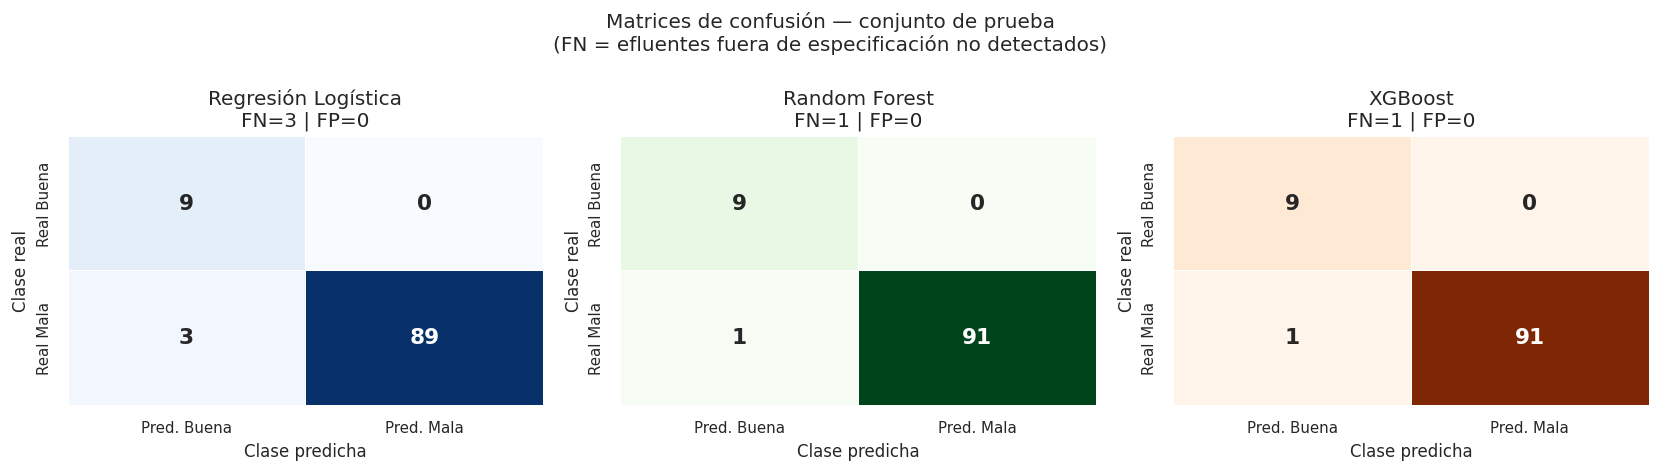


  Figura 12 guardada: fig12_matrices_confusion.png

MÉTRICAS DE CLASIFICACIÓN — CONJUNTO DE PRUEBA

  Regresión Logística:
    Accuracy:        0.9703
    Precision Mala:  1.0000 | Recall Mala:  0.9674 | F1 Mala:  0.9834
    Precision Buena: 0.7500 | Recall Buena: 1.0000 | F1 Buena: 0.8571
    F1 Ponderado:    0.9722
    AUC-ROC:         0.9964
    AUC-PR:          0.9997

  Random Forest:
    Accuracy:        0.9901
    Precision Mala:  1.0000 | Recall Mala:  0.9891 | F1 Mala:  0.9945
    Precision Buena: 0.9000 | Recall Buena: 1.0000 | F1 Buena: 0.9474
    F1 Ponderado:    0.9903
    AUC-ROC:         1.0000
    AUC-PR:          1.0000

  XGBoost:
    Accuracy:        0.9901
    Precision Mala:  1.0000 | Recall Mala:  0.9891 | F1 Mala:  0.9945
    Precision Buena: 0.9000 | Recall Buena: 1.0000 | F1 Buena: 0.9474
    F1 Ponderado:    0.9903
    AUC-ROC:         1.0000
    AUC-PR:          1.0000

CURVAS ROC


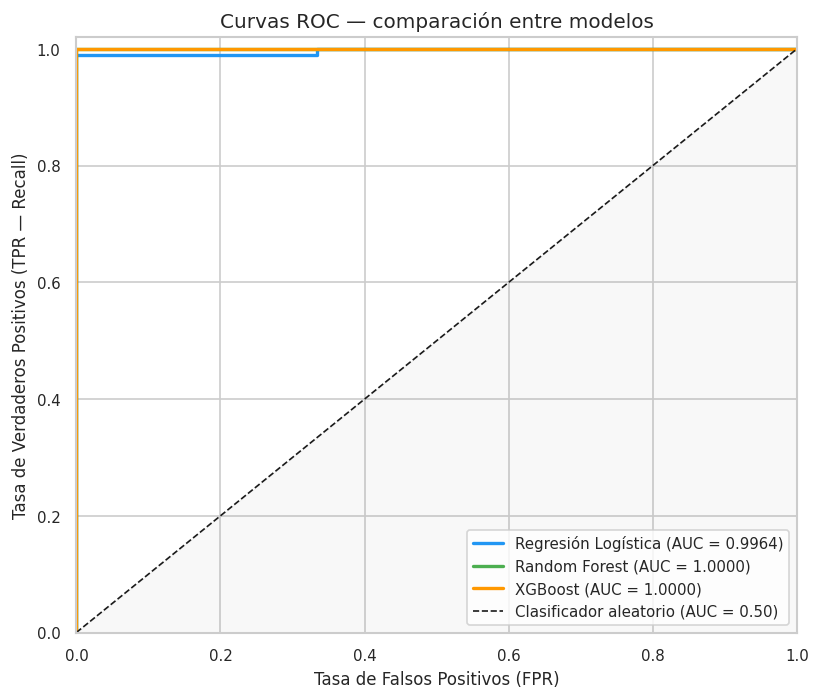

  Figura 13 guardada: fig13_curvas_roc.png


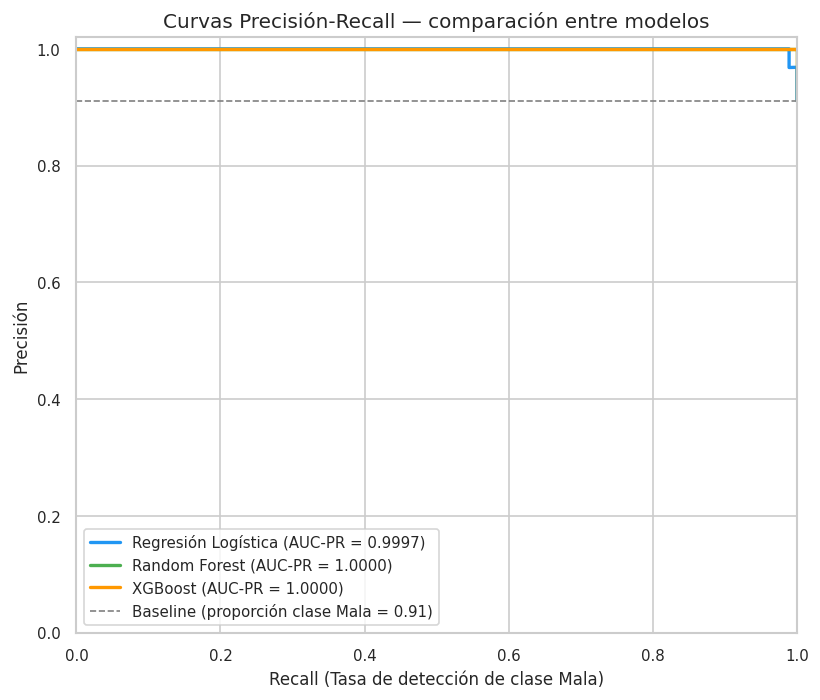

  Figura 14 guardada: fig14_curvas_precision_recall.png


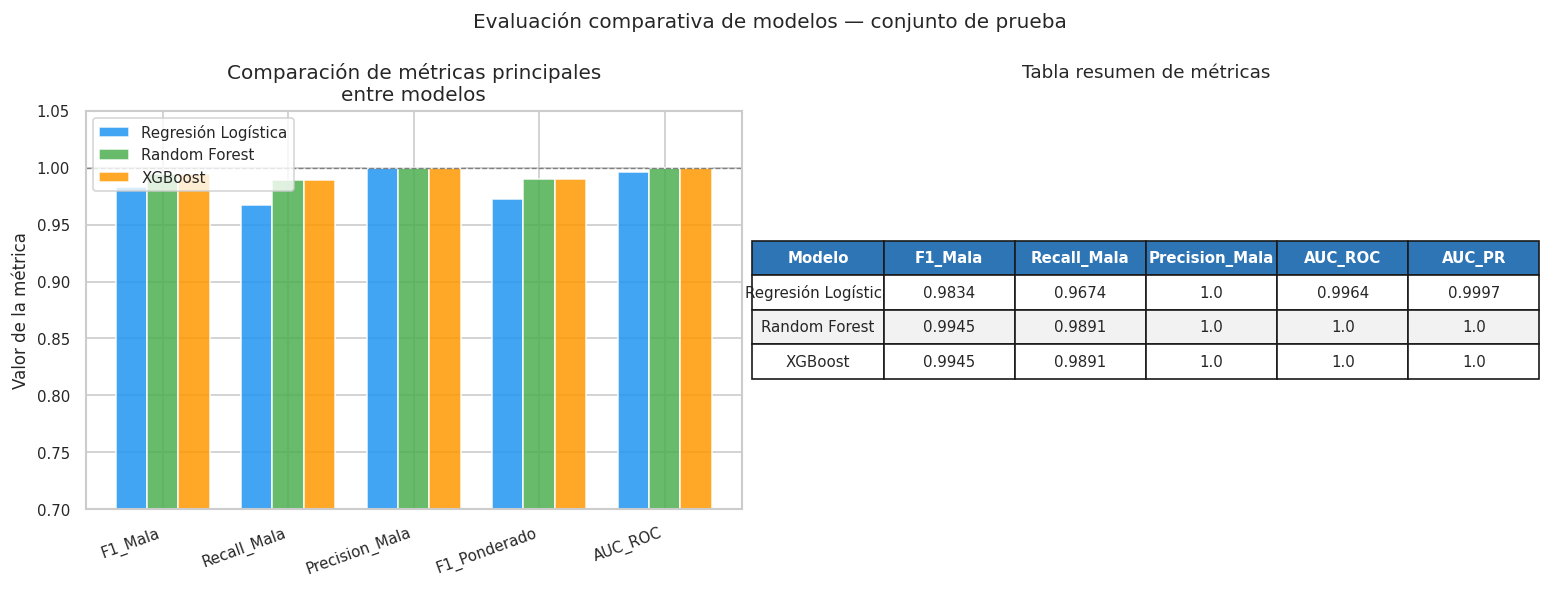

  Figura 15 guardada: fig15_comparacion_metricas.png


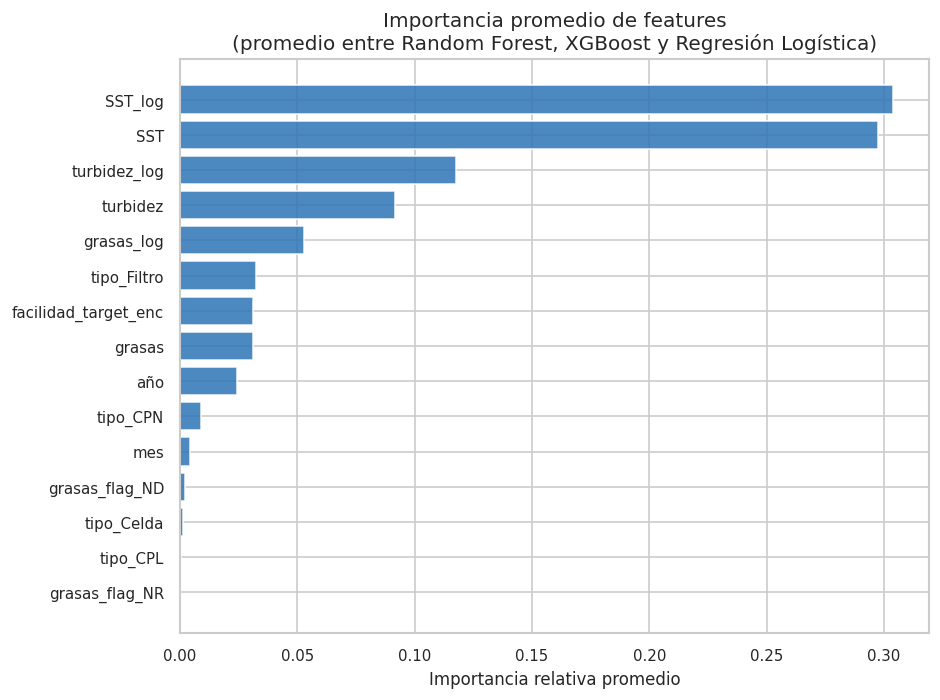

  Figura 16 guardada: fig16_importancia_promedio.png

INTERPRETACIÓN DE RESULTADOS

  Modelo con mejor AUC-ROC: Random Forest
    AUC-ROC:      1.0000
    F1 clase Mala: 0.9945
    Recall Mala:   0.9891

  Referencia operativa:
    Un Recall alto en clase Mala significa que el modelo detecta
    correctamente la mayoría de los efluentes fuera de especificación,
    minimizando el riesgo de daño de formación en el yacimiento.

  Comparación entre modelos:
    Regresión Logística: AUC-ROC=0.9964 | F1_Mala=0.9834 | Recall_Mala=0.9674
    Random Forest: AUC-ROC=1.0000 | F1_Mala=0.9945 | Recall_Mala=0.9891
    XGBoost: AUC-ROC=1.0000 | F1_Mala=0.9945 | Recall_Mala=0.9891

  Reporte exportado: /content/drive/MyDrive/TFM/reporte_evaluacion.csv

SECCIÓN 5 COMPLETADA
Continuar con Sección 6: Detección de anomalías


In [ ]:
# =============================================================================
# SECCIÓN 5: EVALUACIÓN Y COMPARACIÓN DE MODELOS
# =============================================================================
# Este script evalúa el desempeño de los tres modelos entrenados en la
# Sección 4 sobre el conjunto de prueba (datos no vistos durante el
# entrenamiento) y genera la comparación final entre ellos.
#
# Entradas: predicciones_modelos.csv  (predicciones de los tres modelos)
#           importancia_features.csv  (importancia de variables)
#           modelos_entrenados.pkl    (modelos para calcular curvas ROC)
#           X_test.csv, y_test.csv    (conjunto de prueba original)
#
# Salidas:  reporte_evaluacion.csv    (métricas completas por modelo)
#           fig12_matrices_confusion.png
#           fig13_curvas_roc.png
#           fig14_curvas_precision_recall.png
#           fig15_comparacion_metricas.png
#           fig16_importancia_promedio.png
#
# Métricas calculadas:
#   5.1  Matriz de confusión
#   5.2  Precisión, Recall, F1-score por clase
#   5.3  AUC-ROC
#   5.4  Curva Precisión-Recall y AUC-PR
#   5.5  Comparación global entre modelos
#   5.6  Análisis de importancia de features
# =============================================================================

# Instalación de librerías requeridas (descomentar en Google Colab):
# !pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

from google.colab import drive
drive.mount('/content/drive')

CARPETA            = '/content/drive/MyDrive/TFM/'
RUTA_PREDICCIONES  = CARPETA + 'predicciones_modelos.csv'
RUTA_IMPORTANCIA   = CARPETA + 'importancia_features.csv'
RUTA_MODELOS       = CARPETA + 'modelos_entrenados.pkl'
RUTA_X_TEST        = CARPETA + 'X_test.csv'
RUTA_Y_TEST        = CARPETA + 'y_test.csv'
RUTA_REPORTE       = CARPETA + 'reporte_evaluacion.csv'

# =============================================================================
# 5.1 CARGA DE DATOS Y MODELOS
# =============================================================================
predicciones = pd.read_csv(RUTA_PREDICCIONES)
importancias = pd.read_csv(RUTA_IMPORTANCIA)
X_test       = pd.read_csv(RUTA_X_TEST)
y_test       = pd.read_csv(RUTA_Y_TEST).squeeze()

with open(RUTA_MODELOS, 'rb') as f:
    modelos_entrenados = pickle.load(f)

modelos_nombres = ['Regresión Logística', 'Random Forest', 'XGBoost']

print("=" * 60)
print("SECCIÓN 5: EVALUACIÓN Y COMPARACIÓN DE MODELOS")
print("=" * 60)
print(f"  Conjunto de prueba: {len(y_test)} registros")
print(f"    Mala  (1): {(y_test==1).sum()} | Buena (0): {(y_test==0).sum()}")

# =============================================================================
# 5.2 MATRICES DE CONFUSIÓN
# =============================================================================
# La matriz de confusión desglosa las predicciones en cuatro categorías:
#   TP (Verdadero Positivo):  predijo Mala,  era Mala   → detección correcta
#   TN (Verdadero Negativo):  predijo Buena, era Buena  → descarte correcto
#   FP (Falso Positivo):      predijo Mala,  era Buena  → falsa alarma
#   FN (Falso Negativo):      predijo Buena, era Mala   → fallo crítico
#
# En el contexto operativo, los FN son el error más costoso: indican que
# el modelo no detectó un efluente fuera de especificación, lo que puede
# generar daño de formación en el yacimiento receptor.

print("\n" + "=" * 60)
print("MATRICES DE CONFUSIÓN")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colores_cm = ['Blues', 'Greens', 'Oranges']

for ax, nombre, cmap in zip(axes, modelos_nombres, colores_cm):
    y_pred = predicciones[f'pred_{nombre}'].values
    cm     = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Pred. Buena', 'Pred. Mala'],
                yticklabels=['Real Buena', 'Real Mala'],
                linewidths=0.5, linecolor='white', cbar=False,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'{nombre}\nFN={fn} | FP={fp}')
    ax.set_ylabel('Clase real')
    ax.set_xlabel('Clase predicha')

    print(f"\n  {nombre}:")
    print(f"    TP={tp} | TN={tn} | FP={fp} | FN={fn}")
    print(f"    Fallos críticos (FN, Mala no detectada): {fn}")

plt.suptitle('Matrices de confusión — conjunto de prueba\n'
             '(FN = efluentes fuera de especificación no detectados)',
             fontsize=12)
plt.tight_layout()
plt.savefig(CARPETA + 'fig12_matrices_confusion.png', bbox_inches='tight')
plt.show()
print("\n  Figura 12 guardada: fig12_matrices_confusion.png")

# =============================================================================
# 5.3 MÉTRICAS DE CLASIFICACIÓN
# =============================================================================
# Se calculan las métricas estándar para clasificación binaria con clases
# desbalanceadas. La accuracy se incluye por completitud pero no es la métrica
# principal dado el desbalanceo (un modelo que prediga siempre Mala tendría
# accuracy del 91% sin aprender nada útil).
#
# Las métricas relevantes son:
#   Precision: de los que predijo como Mala, ¿cuántos realmente lo eran?
#   Recall:    de los que realmente eran Mala, ¿cuántos detectó?
#   F1-score:  media armónica entre Precision y Recall
#   AUC-ROC:   capacidad discriminativa global del modelo (1=perfecto, 0.5=azar)

print("\n" + "=" * 60)
print("MÉTRICAS DE CLASIFICACIÓN — CONJUNTO DE PRUEBA")
print("=" * 60)

reporte_filas = []

for nombre in modelos_nombres:
    y_pred     = predicciones[f'pred_{nombre}'].values
    y_prob     = predicciones[f'prob_{nombre}'].values

    acc        = accuracy_score(y_test, y_pred)
    prec_mala  = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_mala   = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_mala    = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    prec_buena = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec_buena  = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1_buena   = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1_pond    = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc_roc    = roc_auc_score(y_test, y_prob)
    auc_pr     = average_precision_score(y_test, y_prob)

    reporte_filas.append({
        'Modelo':            nombre,
        'Accuracy':          round(acc, 4),
        'Precision_Mala':    round(prec_mala, 4),
        'Recall_Mala':       round(rec_mala, 4),
        'F1_Mala':           round(f1_mala, 4),
        'Precision_Buena':   round(prec_buena, 4),
        'Recall_Buena':      round(rec_buena, 4),
        'F1_Buena':          round(f1_buena, 4),
        'F1_Ponderado':      round(f1_pond, 4),
        'AUC_ROC':           round(auc_roc, 4),
        'AUC_PR':            round(auc_pr, 4),
    })

    print(f"\n  {nombre}:")
    print(f"    Accuracy:        {acc:.4f}")
    print(f"    Precision Mala:  {prec_mala:.4f} | Recall Mala:  {rec_mala:.4f} | F1 Mala:  {f1_mala:.4f}")
    print(f"    Precision Buena: {prec_buena:.4f} | Recall Buena: {rec_buena:.4f} | F1 Buena: {f1_buena:.4f}")
    print(f"    F1 Ponderado:    {f1_pond:.4f}")
    print(f"    AUC-ROC:         {auc_roc:.4f}")
    print(f"    AUC-PR:          {auc_pr:.4f}")

reporte_df = pd.DataFrame(reporte_filas)

# =============================================================================
# 5.4 CURVAS ROC
# =============================================================================
print("\n" + "=" * 60)
print("CURVAS ROC")
print("=" * 60)

fig, ax = plt.subplots(figsize=(7, 6))
colores = ['#2196F3', '#4CAF50', '#FF9800']

for nombre, color in zip(modelos_nombres, colores):
    y_prob    = predicciones[f'prob_{nombre}'].values
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc       = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nombre} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR — Recall)')
ax.set_title('Curvas ROC — comparación entre modelos')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(CARPETA + 'fig13_curvas_roc.png', bbox_inches='tight')
plt.show()
print("  Figura 13 guardada: fig13_curvas_roc.png")

# =============================================================================
# 5.5 CURVAS PRECISIÓN-RECALL
# =============================================================================
# La curva Precisión-Recall es más informativa que la ROC cuando las clases
# están desbalanceadas, porque se centra exclusivamente en el desempeño sobre
# la clase minoritaria (Buena=0 en este caso, que es la más difícil de detectar).

fig, ax = plt.subplots(figsize=(7, 6))

for nombre, color in zip(modelos_nombres, colores):
    y_prob        = predicciones[f'prob_{nombre}'].values
    prec, rec, _  = precision_recall_curve(y_test, y_prob)
    auc_pr        = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{nombre} (AUC-PR = {auc_pr:.4f})')

proporcion_positivos = y_test.mean()
ax.axhline(y=proporcion_positivos, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline (proporción clase Mala = {proporcion_positivos:.2f})')
ax.set_xlabel('Recall (Tasa de detección de clase Mala)')
ax.set_ylabel('Precisión')
ax.set_title('Curvas Precisión-Recall — comparación entre modelos')
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(CARPETA + 'fig14_curvas_precision_recall.png', bbox_inches='tight')
plt.show()
print("  Figura 14 guardada: fig14_curvas_precision_recall.png")

# =============================================================================
# 5.6 COMPARACIÓN GLOBAL DE MÉTRICAS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metricas_comparar = ['F1_Mala', 'Recall_Mala', 'Precision_Mala', 'F1_Ponderado', 'AUC_ROC']
x     = np.arange(len(metricas_comparar))
width = 0.25

for i, (nombre, color) in enumerate(zip(modelos_nombres, colores)):
    valores = [reporte_df.loc[reporte_df['Modelo']==nombre, m].values[0]
               for m in metricas_comparar]
    bars = axes[0].bar(x + i*width, valores, width, label=nombre,
                       color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metricas_comparar, rotation=20, ha='right')
axes[0].set_ylim(0.7, 1.05)
axes[0].set_ylabel('Valor de la métrica')
axes[0].set_title('Comparación de métricas principales\nentre modelos')
axes[0].legend(fontsize=9)
axes[0].axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

# Tabla resumen
tabla_datos = reporte_df[['Modelo', 'F1_Mala', 'Recall_Mala',
                           'Precision_Mala', 'AUC_ROC', 'AUC_PR']].copy()
axes[1].axis('off')
tabla = axes[1].table(
    cellText=tabla_datos.values,
    colLabels=tabla_datos.columns,
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1.2, 2.0)
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2E75B6')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F2F2F2')
axes[1].set_title('Tabla resumen de métricas', fontsize=11, pad=20)

plt.suptitle('Evaluación comparativa de modelos — conjunto de prueba', fontsize=12)
plt.tight_layout()
plt.savefig(CARPETA + 'fig15_comparacion_metricas.png', bbox_inches='tight')
plt.show()
print("  Figura 15 guardada: fig15_comparacion_metricas.png")

# =============================================================================
# 5.7 IMPORTANCIA DE FEATURES — PROMEDIO ENTRE MODELOS
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 6))
top15 = importancias.nlargest(15, 'importancia_promedio')
colores_imp = ['#E53935' if 'log' not in f and f in ['SST','grasas','turbidez']
               else '#2E75B6' for f in top15['feature']]

ax.barh(top15['feature'], top15['importancia_promedio'],
        color='#2E75B6', alpha=0.85, edgecolor='white')
ax.set_title('Importancia promedio de features\n(promedio entre Random Forest, XGBoost y Regresión Logística)')
ax.set_xlabel('Importancia relativa promedio')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(CARPETA + 'fig16_importancia_promedio.png', bbox_inches='tight')
plt.show()
print("  Figura 16 guardada: fig16_importancia_promedio.png")

# =============================================================================
# 5.8 INTERPRETACIÓN DE RESULTADOS
# =============================================================================
mejor_modelo = reporte_df.loc[reporte_df['AUC_ROC'].idxmax(), 'Modelo']
mejor_auc    = reporte_df['AUC_ROC'].max()
mejor_f1     = reporte_df.loc[reporte_df['AUC_ROC'].idxmax(), 'F1_Mala']
mejor_recall = reporte_df.loc[reporte_df['AUC_ROC'].idxmax(), 'Recall_Mala']

print("\n" + "=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)
print(f"\n  Modelo con mejor AUC-ROC: {mejor_modelo}")
print(f"    AUC-ROC:      {mejor_auc:.4f}")
print(f"    F1 clase Mala: {mejor_f1:.4f}")
print(f"    Recall Mala:   {mejor_recall:.4f}")
print(f"\n  Referencia operativa:")
print(f"    Un Recall alto en clase Mala significa que el modelo detecta")
print(f"    correctamente la mayoría de los efluentes fuera de especificación,")
print(f"    minimizando el riesgo de daño de formación en el yacimiento.")
print(f"\n  Comparación entre modelos:")
for _, row in reporte_df.iterrows():
    print(f"    {row['Modelo']}: AUC-ROC={row['AUC_ROC']:.4f} | "
          f"F1_Mala={row['F1_Mala']:.4f} | Recall_Mala={row['Recall_Mala']:.4f}")

# =============================================================================
# 5.9 EXPORTACIÓN DEL REPORTE
# =============================================================================
reporte_df.to_csv(RUTA_REPORTE, index=False)
print(f"\n  Reporte exportado: {RUTA_REPORTE}")

print("\n" + "=" * 60)
print("SECCIÓN 5 COMPLETADA")
print("Continuar con Sección 6: Detección de anomalías")
print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SECCIÓN 6: DETECCIÓN DE ANOMALÍAS — ISOLATION FOREST
  Dataset cargado: 502 registros x 23 columnas

  Isolation Forest entrenado:
    Total registros analizados: 502
    Anomalías detectadas:       51 (10.2%)
    Registros normales:         451

RELACIÓN ANOMALÍAS DETECTADAS vs. ETIQUETA DE CALIDAD

Calidad real  Buena  Mala
Anomalía IF              
0                40   411
1                 3    48

  Anomalías coincidentes con calidad Mala: 48/51 (94.1%)
  Interpretación: el 94.1% de las anomalías detectadas
  por Isolation Forest corresponde a registros etiquetados como Mala,
  lo que valida la capacidad del detector para identificar condiciones
  operativas fuera de especificación sin usar las etiquetas.


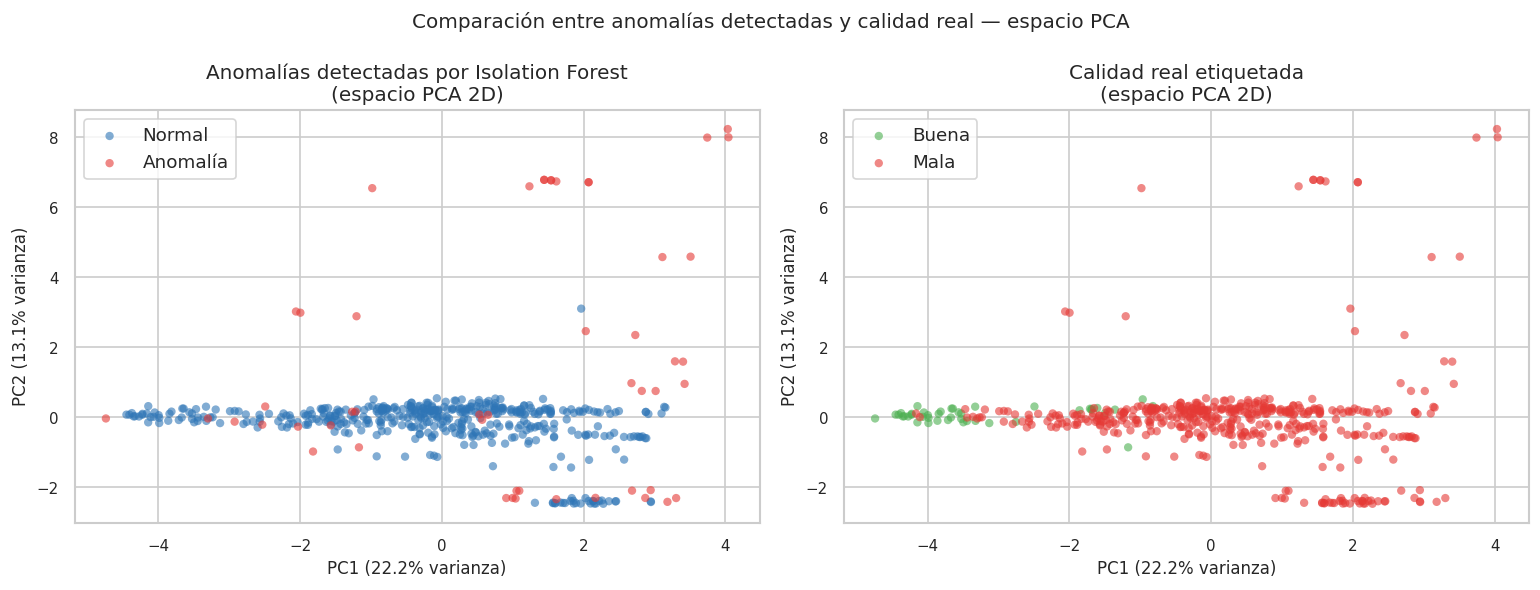


  Figura 17 guardada: fig17_anomalias_pca.png


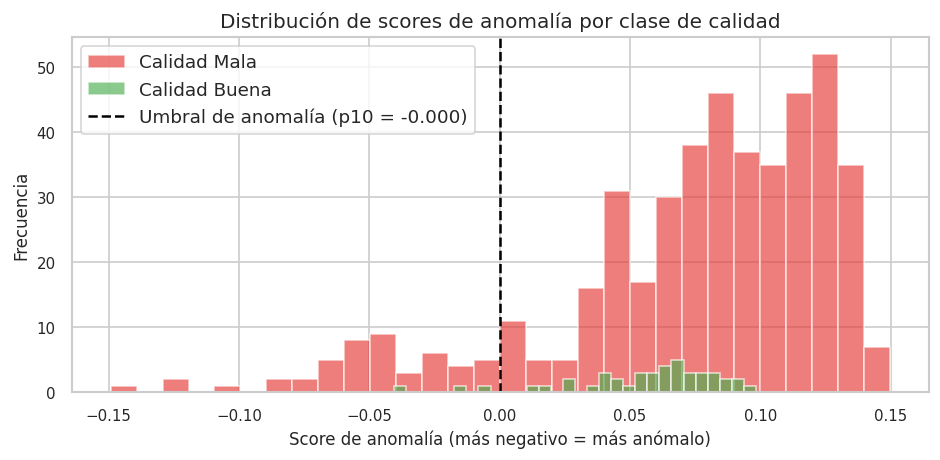

  Figura 18 guardada: fig18_scores_anomalia.png


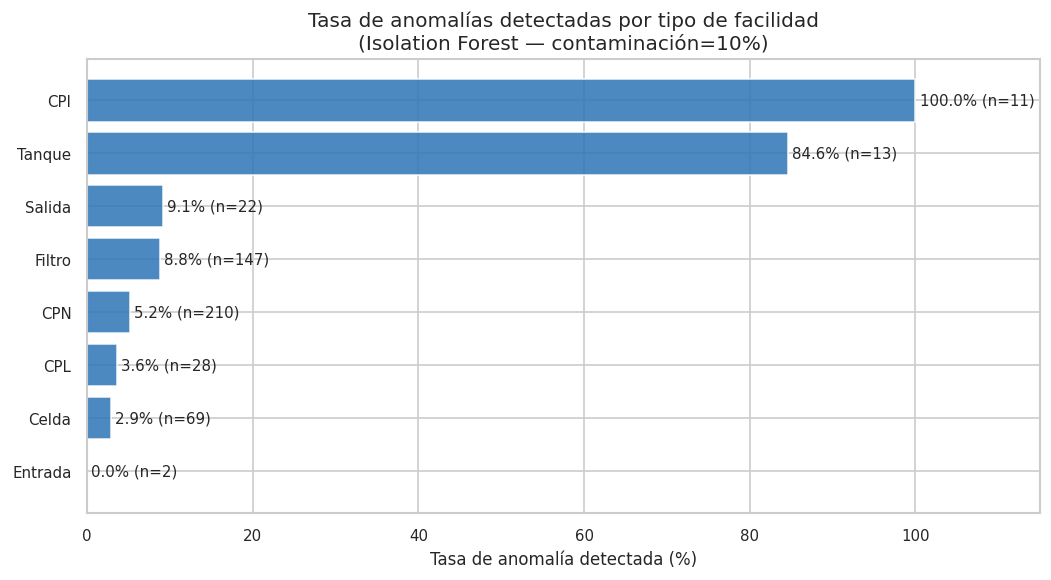

  Figura 19 guardada: fig19_anomalias_por_facilidad.png


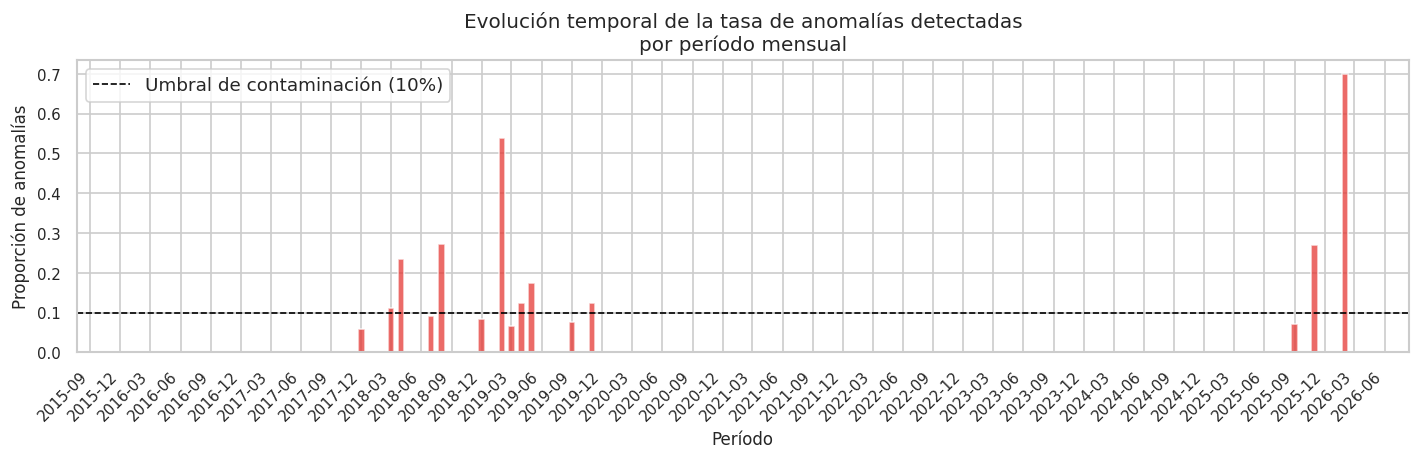

  Figura 20 guardada: fig20_anomalias_temporal.png

EXPORTACIÓN
  /content/drive/MyDrive/TFM/anomalias_detectadas.csv → 502 registros con score y etiqueta de anomalía

SECCIÓN 6 COMPLETADA
Continuar con Sección 7: Exportación de resultados y resumen final


In [ ]:
# =============================================================================
# SECCIÓN 6: DETECCIÓN DE ANOMALÍAS
# =============================================================================
# Este script implementa un módulo de detección de anomalías no supervisado
# sobre el dataset completo de operación, complementando los modelos predictivos
# de clasificación desarrollados en las secciones anteriores.
#
# Mientras los modelos de la Sección 4 requieren una etiqueta conocida
# (Mala/Buena) para hacer predicciones, el detector de anomalías aprende
# el comportamiento normal del proceso sin necesidad de etiquetas y señala
# automáticamente los registros que se desvían de ese comportamiento.
# Esto es especialmente valioso en operación real, donde los eventos de falla
# no siempre han sido catalogados previamente.
#
# Entrada:  datos_limpios.csv
# Salidas:  anomalias_detectadas.csv
#           fig17_anomalias_pca.png
#           fig18_scores_anomalia.png
#           fig19_anomalias_por_facilidad.png
#           fig20_anomalias_temporal.png
#
# Algoritmo utilizado: Isolation Forest
#   Construye árboles de aislamiento aleatorios. Los registros anómalos son
#   aquellos que requieren menos particiones para ser aislados, es decir,
#   los que se encuentran en regiones poco densas del espacio de features.
#   Es robusto en alta dimensionalidad y eficiente computacionalmente.
# =============================================================================

# Instalación de librerías requeridas (descomentar en Google Colab):
# !pip install scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

from google.colab import drive
drive.mount('/content/drive')

CARPETA         = '/content/drive/MyDrive/TFM/'
RUTA_ENTRADA    = CARPETA + 'datos_limpios.csv'
RUTA_ANOMALIAS  = CARPETA + 'anomalias_detectadas.csv'

# =============================================================================
# 6.1 CARGA DE DATOS
# =============================================================================
df = pd.read_csv(RUTA_ENTRADA, parse_dates=['fecha'])

print("=" * 60)
print("SECCIÓN 6: DETECCIÓN DE ANOMALÍAS — ISOLATION FOREST")
print("=" * 60)
print(f"  Dataset cargado: {df.shape[0]} registros x {df.shape[1]} columnas")

# Features utilizados para la detección de anomalías.
# Se usan las versiones log1p de las variables continuas para reducir la
# influencia de los valores extremos en la construcción de los árboles.
# Las variables binarias de tipo y de flags se incluyen porque aportan
# contexto sobre el punto de muestreo y la calidad del dato.

features_anomalia = [
    'SST_log', 'grasas_log', 'turbidez_log',
    'facilidad_target_enc', 'año', 'mes',
    'grasas_flag_NR', 'grasas_flag_ND', 'turbidez_flag_NR',
]

# Incluir columnas OHE que existan en el dataset
# Se excluye 'tipo_facilidad' (texto) y se conservan solo las columnas OHE binarias
cols_ohe = [c for c in df.columns if c.startswith('tipo_') and c != 'tipo_facilidad']
features_anomalia += cols_ohe
features_anomalia  = [f for f in features_anomalia if f in df.columns]

X_anomalia = df[features_anomalia].copy()

# =============================================================================
# 6.2 ESCALADO
# =============================================================================
scaler     = StandardScaler()
X_escalado = scaler.fit_transform(X_anomalia)

# =============================================================================
# 6.3 ENTRENAMIENTO DEL ISOLATION FOREST
# =============================================================================
# contamination: proporción esperada de anomalías en el dataset.
# Se fija en 0.10 (10%) como estimación conservadora basada en la distribución
# conocida de registros con calidad Mala en puntos críticos del proceso.
# n_estimators=200 proporciona estabilidad suficiente para este tamaño de dataset.
# random_state=42 garantiza reproducibilidad.

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_escalado)

# Scores de anomalía: valores más negativos indican mayor anomalía
scores          = iso_forest.decision_function(X_escalado)
predicciones_if = iso_forest.predict(X_escalado)  # -1=anomalía, 1=normal

# Convertir a formato interpretable: 1=anomalía, 0=normal
df['anomalia']       = (predicciones_if == -1).astype(int)
df['score_anomalia'] = scores.round(6)

n_anomalias = df['anomalia'].sum()
print(f"\n  Isolation Forest entrenado:")
print(f"    Total registros analizados: {len(df)}")
print(f"    Anomalías detectadas:       {n_anomalias} ({n_anomalias/len(df)*100:.1f}%)")
print(f"    Registros normales:         {len(df) - n_anomalias}")

# =============================================================================
# 6.4 RELACIÓN ENTRE ANOMALÍAS Y CALIDAD ETIQUETADA
# =============================================================================
# Se verifica qué proporción de las anomalías detectadas corresponde a
# registros con calidad 'Mala' según las etiquetas del dataset. Una alta
# coincidencia valida que el detector está capturando condiciones operativas
# reales de desviación, no ruido aleatorio.

print("\n" + "=" * 60)
print("RELACIÓN ANOMALÍAS DETECTADAS vs. ETIQUETA DE CALIDAD")
print("=" * 60)

tabla_cruce = pd.crosstab(df['anomalia'], df['Calidad'],
                           rownames=['Anomalía IF'], colnames=['Calidad real'])
print(f"\n{tabla_cruce}")

anomalias_malas = df[(df['anomalia']==1) & (df['Calidad']=='Mala')].shape[0]
anomalias_total = df['anomalia'].sum()
coincidencia    = anomalias_malas / anomalias_total * 100

print(f"\n  Anomalías coincidentes con calidad Mala: "
      f"{anomalias_malas}/{anomalias_total} ({coincidencia:.1f}%)")
print(f"  Interpretación: el {coincidencia:.1f}% de las anomalías detectadas")
print(f"  por Isolation Forest corresponde a registros etiquetados como Mala,")
print(f"  lo que valida la capacidad del detector para identificar condiciones")
print(f"  operativas fuera de especificación sin usar las etiquetas.")

# =============================================================================
# 6.5 VISUALIZACIÓN — PCA 2D
# =============================================================================
# Se reduce la dimensionalidad a 2 componentes principales para visualizar
# la distribución de anomalías en el espacio de features. PCA no se usa
# para el modelado, solo para visualización.

pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_escalado)
var_expl  = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: anomalías vs. normales
colores_if = {0: '#2E75B6', 1: '#E53935'}
labels_if  = {0: 'Normal', 1: 'Anomalía'}
for clase in [0, 1]:
    mask = df['anomalia'] == clase
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores_if[clase], label=labels_if[clase],
                    alpha=0.6, s=25, edgecolors='none')
axes[0].set_title('Anomalías detectadas por Isolation Forest\n(espacio PCA 2D)')
axes[0].set_xlabel(f'PC1 ({var_expl[0]*100:.1f}% varianza)')
axes[0].set_ylabel(f'PC2 ({var_expl[1]*100:.1f}% varianza)')
axes[0].legend()

# Panel derecho: calidad real etiquetada
colores_cal = {'Mala': '#E53935', 'Buena': '#4CAF50'}
for clase in ['Buena', 'Mala']:
    mask = df['Calidad'] == clase
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colores_cal[clase], label=clase,
                    alpha=0.6, s=25, edgecolors='none')
axes[1].set_title('Calidad real etiquetada\n(espacio PCA 2D)')
axes[1].set_xlabel(f'PC1 ({var_expl[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({var_expl[1]*100:.1f}% varianza)')
axes[1].legend()

plt.suptitle('Comparación entre anomalías detectadas y calidad real — espacio PCA',
             fontsize=12)
plt.tight_layout()
plt.savefig(CARPETA + 'fig17_anomalias_pca.png', bbox_inches='tight')
plt.show()
print("\n  Figura 17 guardada: fig17_anomalias_pca.png")

# =============================================================================
# 6.6 DISTRIBUCIÓN DE SCORES DE ANOMALÍA
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 4))

for clase, color, label in [('Mala', '#E53935', 'Calidad Mala'),
                              ('Buena', '#4CAF50', 'Calidad Buena')]:
    mask = df['Calidad'] == clase
    ax.hist(df.loc[mask, 'score_anomalia'], bins=30,
            alpha=0.65, color=color, label=label, edgecolor='white')

umbral = np.percentile(scores, 10)
ax.axvline(x=umbral, color='black', linestyle='--', linewidth=1.5,
           label=f'Umbral de anomalía (p10 = {umbral:.3f})')
ax.set_xlabel('Score de anomalía (más negativo = más anómalo)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de scores de anomalía por clase de calidad')
ax.legend()
plt.tight_layout()
plt.savefig(CARPETA + 'fig18_scores_anomalia.png', bbox_inches='tight')
plt.show()
print("  Figura 18 guardada: fig18_scores_anomalia.png")

# =============================================================================
# 6.7 ANOMALÍAS POR TIPO DE FACILIDAD
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 5))

resumen_facilidad = df.groupby('tipo_facilidad').agg(
    total=('anomalia', 'count'),
    anomalias=('anomalia', 'sum')
).reset_index()
resumen_facilidad['tasa_anomalia'] = (
    resumen_facilidad['anomalias'] / resumen_facilidad['total'] * 100
).round(1)
resumen_facilidad = resumen_facilidad.sort_values('tasa_anomalia', ascending=True)

bars = ax.barh(resumen_facilidad['tipo_facilidad'],
               resumen_facilidad['tasa_anomalia'],
               color='#2E75B6', alpha=0.85, edgecolor='white')

for bar, tasa, total in zip(bars,
                             resumen_facilidad['tasa_anomalia'],
                             resumen_facilidad['total']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{tasa}% (n={total})', va='center', fontsize=9)

ax.set_xlabel('Tasa de anomalía detectada (%)')
ax.set_title('Tasa de anomalías detectadas por tipo de facilidad\n'
             '(Isolation Forest — contaminación=10%)')
ax.set_xlim(0, resumen_facilidad['tasa_anomalia'].max() + 15)
plt.tight_layout()
plt.savefig(CARPETA + 'fig19_anomalias_por_facilidad.png', bbox_inches='tight')
plt.show()
print("  Figura 19 guardada: fig19_anomalias_por_facilidad.png")

# =============================================================================
# 6.8 DISTRIBUCIÓN TEMPORAL DE ANOMALÍAS
# =============================================================================
df_tiempo = df.dropna(subset=['fecha']).copy()
df_tiempo['año_mes'] = df_tiempo['fecha'].dt.to_period('M').dt.to_timestamp()

temporal = df_tiempo.groupby('año_mes').agg(
    total=('anomalia', 'count'),
    anomalias=('anomalia', 'sum')
).reset_index()
temporal['tasa'] = temporal['anomalias'] / temporal['total']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(temporal['año_mes'], temporal['tasa'],
       color='#E53935', alpha=0.75, edgecolor='white', width=20)
ax.set_xlabel('Período')
ax.set_ylabel('Proporción de anomalías')
ax.set_title('Evolución temporal de la tasa de anomalías detectadas\npor período mensual')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.axhline(y=0.10, color='black', linestyle='--', linewidth=1,
           label='Umbral de contaminación (10%)')
ax.legend()
plt.tight_layout()
plt.savefig(CARPETA + 'fig20_anomalias_temporal.png', bbox_inches='tight')
plt.show()
print("  Figura 20 guardada: fig20_anomalias_temporal.png")

# =============================================================================
# 6.9 EXPORTACIÓN
# =============================================================================
cols_exportar = ['fecha', 'Facilidad', 'tipo_facilidad',
                 'SST', 'grasas', 'turbidez',
                 'Calidad', 'Calidad_num',
                 'anomalia', 'score_anomalia']
cols_exportar = [c for c in cols_exportar if c in df.columns]

df[cols_exportar].to_csv(RUTA_ANOMALIAS, index=False)

print("\n" + "=" * 60)
print("EXPORTACIÓN")
print("=" * 60)
print(f"  {RUTA_ANOMALIAS} → {len(df)} registros con score y etiqueta de anomalía")

print("\n" + "=" * 60)
print("SECCIÓN 6 COMPLETADA")
print("Continuar con Sección 7: Exportación de resultados y resumen final")
print("=" * 60)


In [ ]:
# =============================================================================
# SECCIÓN 7: EXPORTACIÓN DE RESULTADOS Y RESUMEN FINAL
# =============================================================================
# Este script consolida todos los resultados generados en las secciones
# anteriores en un único reporte ejecutivo en formato Excel, listo para
# incluir en la memoria del TFE y presentar en la defensa.
#
# Entradas:  reporte_evaluacion.csv     (métricas de los modelos)
#            importancia_features.csv   (importancia de variables)
#            anomalias_detectadas.csv   (dataset con etiquetas de anomalía)
#            predicciones_modelos.csv   (predicciones sobre conjunto de prueba)
#
# Salidas:   reporte_final_TFM.xlsx     (reporte consolidado multi-hoja)
#
# Contenido del reporte Excel:
#   Hoja 1 — Resumen ejecutivo del proyecto
#   Hoja 2 — Métricas de evaluación de los tres modelos
#   Hoja 3 — Importancia de features
#   Hoja 4 — Registro de anomalías detectadas
#   Hoja 5 — Inventario de archivos generados
# =============================================================================

# Instalación de librerías requeridas (descomentar en Google Colab):
# !pip install openpyxl -q

import pandas as pd
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

CARPETA           = '/content/drive/MyDrive/TFM/'
RUTA_REPORTE_CSV  = CARPETA + 'reporte_evaluacion.csv'
RUTA_IMPORTANCIA  = CARPETA + 'importancia_features.csv'
RUTA_ANOMALIAS    = CARPETA + 'anomalias_detectadas.csv'
RUTA_PREDICCIONES = CARPETA + 'predicciones_modelos.csv'
RUTA_SALIDA       = CARPETA + 'reporte_final_TFM.xlsx'

print("=" * 60)
print("SECCIÓN 7: EXPORTACIÓN DE RESULTADOS Y RESUMEN FINAL")
print("=" * 60)

# =============================================================================
# 7.1 CARGA DE RESULTADOS
# =============================================================================
reporte_eval  = pd.read_csv(RUTA_REPORTE_CSV)
importancias  = pd.read_csv(RUTA_IMPORTANCIA)
anomalias     = pd.read_csv(RUTA_ANOMALIAS, parse_dates=['fecha'])
predicciones  = pd.read_csv(RUTA_PREDICCIONES)

print(f"  Archivos de resultados cargados correctamente.")

# Identificar el mejor modelo según AUC-ROC
mejor_modelo  = reporte_eval.loc[reporte_eval['AUC_ROC'].idxmax(), 'Modelo']
mejor_auc     = reporte_eval['AUC_ROC'].max()
mejor_f1      = reporte_eval.loc[reporte_eval['AUC_ROC'].idxmax(), 'F1_Mala']
mejor_recall  = reporte_eval.loc[reporte_eval['AUC_ROC'].idxmax(), 'Recall_Mala']
n_anomalias   = anomalias['anomalia'].sum()
coinc_anomalia = anomalias[(anomalias['anomalia']==1) &
                            (anomalias['Calidad']=='Mala')].shape[0]
pct_coinc     = coinc_anomalia / n_anomalias * 100

# =============================================================================
# 7.2 CONSTRUCCIÓN DEL LIBRO EXCEL
# =============================================================================

# Paleta de colores institucional
NAVY   = "1B3A6B"
BLUE   = "2E75B6"
LGRAY  = "F2F2F2"
WHITE  = "FFFFFF"
GREEN  = "E2EFDA"
RED    = "FCE4D6"
YELLOW = "FFF2CC"

def estilo_encabezado(cell, bg=NAVY, fg=WHITE, size=10, bold=True):
    cell.font      = Font(bold=bold, color=fg, size=size, name='Arial')
    cell.fill      = PatternFill('solid', start_color=bg)
    cell.alignment = Alignment(horizontal='center', vertical='center',
                                wrap_text=True)

def estilo_dato(cell, bg=WHITE, bold=False, size=9, alineacion='left'):
    cell.font      = Font(bold=bold, color='000000', size=size, name='Arial')
    cell.fill      = PatternFill('solid', start_color=bg)
    cell.alignment = Alignment(horizontal=alineacion, vertical='center',
                                wrap_text=True)

def borde_fino():
    s = Side(style='thin', color='CCCCCC')
    return Border(left=s, right=s, top=s, bottom=s)

wb = Workbook()

# =========================================================================
# HOJA 1: RESUMEN EJECUTIVO
# =========================================================================
ws1 = wb.active
ws1.title = "Resumen_Ejecutivo"

resumen_contenido = [
    ("PROYECTO", "Desarrollo de un modelo predictivo basado en machine learning para la "
                 "evaluación del desempeño y detección de anomalías en sistemas de "
                 "tratamiento de agua de producción"),
    ("Máster", "Máster Universitario en Transformación Digital a través de Tecnologías Disruptivas"),
    ("Universidad", "Universidad Internacional de La Rioja (UNIR)"),
    ("Autores", "Fredy Muñoz Bermúdez | Ivan D Mejia Segura | Jorge Andrés Suárez C"),
    ("Director", "Gabriel Pares Mahedero"),
    ("Fecha", "2026"),
    ("", ""),
    ("DATASET", ""),
    ("Fuente de datos", "Planta de tratamiento de agua de producción — Estación 1"),
    ("Período", "Febrero 2016 – Febrero 2026 (con gap 2020–2024)"),
    ("Registros totales", "502"),
    ("Variables originales", "7 (fecha, Facilidad, estación, SST, grasas, turbidez, Calidad)"),
    ("Variables tras preprocesamiento", "24"),
    ("Distribución de clases", "Mala: 459 (91.4%) | Buena: 43 (8.6%) — Ratio 10.7:1"),
    ("", ""),
    ("PREPROCESAMIENTO", ""),
    ("Valores especiales tratados", "NR → NaN (fallo medición) | ND → 0 (bajo umbral detección)"),
    ("Imputación de nulos", "Mediana por Facilidad + Calidad (SST: 55 nulos, grasas: 16, turbidez: 25)"),
    ("Control de outliers", "Winsorizing percentil 1–99"),
    ("Encoding categórico", "58 facilidades → 9 tipos + Target Encoding + One-Hot Encoding"),
    ("Transformación", "log1p sobre SST, grasas y turbidez (distribuciones sesgadas)"),
    ("", ""),
    ("MODELADO", ""),
    ("División train/test", "80% entrenamiento / 20% prueba — estratificada por clase"),
    ("Balanceo de clases", "SMOTE sobre conjunto de entrenamiento (367 → 734 registros)"),
    ("Modelos entrenados", "Regresión Logística | Random Forest | XGBoost"),
    ("Validación", "Validación cruzada estratificada — 5 folds — métrica F1 ponderado"),
    ("", ""),
    ("RESULTADOS PRINCIPALES", ""),
    ("Mejor modelo (AUC-ROC)", f"{mejor_modelo} — AUC-ROC: {mejor_auc:.4f}"),
    ("F1-score clase Mala", f"{mejor_f1:.4f}"),
    ("Recall clase Mala", f"{mejor_recall:.4f}  (proporción de efluentes fuera de especificación detectados)"),
    ("", ""),
    ("DETECCIÓN DE ANOMALÍAS", ""),
    ("Algoritmo", "Isolation Forest (no supervisado) — contamination=10%"),
    ("Anomalías detectadas", f"{n_anomalias} de 502 registros ({n_anomalias/502*100:.1f}%)"),
    ("Coincidencia con calidad Mala", f"{coinc_anomalia}/{n_anomalias} ({pct_coinc:.1f}%) — valida el detector"),
]

ws1.column_dimensions['A'].width = 32
ws1.column_dimensions['B'].width = 72

# Título principal
ws1.merge_cells('A1:B1')
ws1['A1'] = 'REPORTE FINAL — MODELO PREDICTIVO TRATAMIENTO DE AGUA DE PRODUCCIÓN'
estilo_encabezado(ws1['A1'], bg=NAVY, size=13)
ws1.row_dimensions[1].height = 32

fila = 2
for campo, valor in resumen_contenido:
    ws1.row_dimensions[fila].height = 22
    if campo == "" and valor == "":
        fila += 1
        continue
    if valor == "":
        # Encabezado de sección
        ws1.merge_cells(f'A{fila}:B{fila}')
        cell = ws1[f'A{fila}']
        cell.value = campo
        estilo_encabezado(cell, bg=BLUE, size=10)
    else:
        cell_a = ws1[f'A{fila}']
        cell_b = ws1[f'B{fila}']
        cell_a.value = campo
        cell_b.value = valor
        bg = LGRAY if fila % 2 == 0 else WHITE
        estilo_dato(cell_a, bg=bg, bold=True)
        estilo_dato(cell_b, bg=bg)
        cell_a.border = borde_fino()
        cell_b.border = borde_fino()
    fila += 1

# =========================================================================
# HOJA 2: MÉTRICAS DE EVALUACIÓN
# =========================================================================
ws2 = wb.create_sheet("Metricas_Evaluacion")

ws2.merge_cells('A1:K1')
ws2['A1'] = 'MÉTRICAS DE EVALUACIÓN — CONJUNTO DE PRUEBA (101 registros)'
estilo_encabezado(ws2['A1'], bg=NAVY, size=12)
ws2.row_dimensions[1].height = 28

metricas_cols = list(reporte_eval.columns)
anchos = [22, 11, 16, 14, 10, 16, 14, 10, 14, 10, 10]
for j, (col, ancho) in enumerate(zip(metricas_cols, anchos), 1):
    cell = ws2.cell(row=2, column=j, value=col)
    estilo_encabezado(cell, bg=BLUE, size=9)
    ws2.column_dimensions[get_column_letter(j)].width = ancho
ws2.row_dimensions[2].height = 28

for i, row in enumerate(reporte_eval.itertuples(index=False), 3):
    ws2.row_dimensions[i].height = 22
    bg = LGRAY if i % 2 == 0 else WHITE
    for j, val in enumerate(row, 1):
        cell = ws2.cell(row=i, column=j, value=val)
        estilo_dato(cell, bg=bg, alineacion='center')
        cell.border = borde_fino()
        # Resaltar mejor valor por columna métrica
        if j > 1 and isinstance(val, float):
            col_name = metricas_cols[j-1]
            max_val  = reporte_eval[col_name].max()
            if val == max_val:
                cell.fill = PatternFill('solid', start_color=GREEN)

# Nota metodológica
nota_fila = 3 + len(reporte_eval) + 1
ws2.merge_cells(f'A{nota_fila}:K{nota_fila}')
ws2[f'A{nota_fila}'] = ('NOTA: Las celdas resaltadas en verde indican el mejor valor por métrica. '
                         'Accuracy no es la métrica principal dado el desbalanceo de clases (91.4% Mala). '
                         'Las métricas relevantes son F1_Mala, Recall_Mala, AUC_ROC y AUC_PR.')
ws2[f'A{nota_fila}'].font      = Font(italic=True, size=8, name='Arial', color='555555')
ws2[f'A{nota_fila}'].alignment = Alignment(wrap_text=True)
ws2.row_dimensions[nota_fila].height = 35

# =========================================================================
# HOJA 3: IMPORTANCIA DE FEATURES
# =========================================================================
ws3 = wb.create_sheet("Importancia_Features")

ws3.merge_cells('A1:F1')
ws3['A1'] = 'IMPORTANCIA DE FEATURES — COMPARACIÓN ENTRE MODELOS'
estilo_encabezado(ws3['A1'], bg=NAVY, size=12)
ws3.row_dimensions[1].height = 28

imp_cols   = ['feature', 'importancia_RF', 'importancia_XGB',
              'importancia_LR', 'importancia_promedio']
imp_anchos = [28, 18, 16, 16, 20]
imp_sorted = importancias.sort_values('importancia_promedio', ascending=False).reset_index(drop=True)

for j, (col, ancho) in enumerate(zip(imp_cols, imp_anchos), 1):
    cell = ws3.cell(row=2, column=j, value=col)
    estilo_encabezado(cell, bg=BLUE, size=9)
    ws3.column_dimensions[get_column_letter(j)].width = ancho
ws3.row_dimensions[2].height = 25

for i, row in enumerate(imp_sorted[imp_cols].itertuples(index=False), 3):
    ws3.row_dimensions[i].height = 20
    bg = LGRAY if i % 2 == 0 else WHITE
    # Top 5 features con fondo amarillo
    if i <= 7:
        bg = YELLOW
    for j, val in enumerate(row, 1):
        cell = ws3.cell(row=i, column=j, value=val)
        estilo_dato(cell, bg=bg, alineacion='center' if j > 1 else 'left')
        cell.border = borde_fino()

# Leyenda
leyenda_fila = 3 + len(imp_sorted) + 1
ws3.merge_cells(f'A{leyenda_fila}:F{leyenda_fila}')
ws3[f'A{leyenda_fila}'] = 'Filas en amarillo: Top 5 features más importantes según importancia promedio entre los tres modelos.'
ws3[f'A{leyenda_fila}'].font = Font(italic=True, size=8, name='Arial', color='555555')

# =========================================================================
# HOJA 4: ANOMALÍAS DETECTADAS
# =========================================================================
ws4 = wb.create_sheet("Anomalias_Detectadas")

ws4.merge_cells('A1:I1')
ws4['A1'] = f'ANOMALÍAS DETECTADAS — ISOLATION FOREST ({n_anomalias} de 502 registros)'
estilo_encabezado(ws4['A1'], bg=NAVY, size=12)
ws4.row_dimensions[1].height = 28

anom_cols   = ['fecha', 'Facilidad', 'tipo_facilidad',
               'SST', 'grasas', 'turbidez',
               'Calidad', 'anomalia', 'score_anomalia']
anom_cols   = [c for c in anom_cols if c in anomalias.columns]
anom_anchos = [14, 16, 14, 10, 10, 10, 10, 10, 16]

for j, (col, ancho) in enumerate(zip(anom_cols, anom_anchos[:len(anom_cols)]), 1):
    cell = ws4.cell(row=2, column=j, value=col)
    estilo_encabezado(cell, bg=BLUE, size=9)
    ws4.column_dimensions[get_column_letter(j)].width = ancho
ws4.row_dimensions[2].height = 25

for i, row in enumerate(anomalias[anom_cols].itertuples(index=False), 3):
    ws4.row_dimensions[i].height = 18
    es_anomalia = row.anomalia == 1
    bg = RED if es_anomalia else (LGRAY if i % 2 == 0 else WHITE)
    for j, val in enumerate(row, 1):
        if hasattr(val, 'strftime'):
            val = val.strftime('%Y-%m-%d')
        elif isinstance(val, float) and np.isnan(val):
            val = ''
        cell = ws4.cell(row=i, column=j, value=val)
        estilo_dato(cell, bg=bg, alineacion='center' if j > 3 else 'left')
        cell.border = borde_fino()

ws4.freeze_panes = 'A3'

# =========================================================================
# HOJA 5: INVENTARIO DE ARCHIVOS
# =========================================================================
ws5 = wb.create_sheet("Inventario_Archivos")

ws5.merge_cells('A1:D1')
ws5['A1'] = 'INVENTARIO DE ARCHIVOS GENERADOS — PROYECTO TFM'
estilo_encabezado(ws5['A1'], bg=NAVY, size=12)
ws5.row_dimensions[1].height = 28

inv_headers = ['Archivo', 'Sección', 'Descripción', 'Tipo']
inv_anchos  = [38, 10, 55, 12]
for j, (h, w) in enumerate(zip(inv_headers, inv_anchos), 1):
    cell = ws5.cell(row=2, column=j, value=h)
    estilo_encabezado(cell, bg=BLUE)
    ws5.column_dimensions[get_column_letter(j)].width = w
ws5.row_dimensions[2].height = 25

inventario = [
    ('seccion1_eda.py',                       'S1', 'Análisis exploratorio de datos (EDA)',                    'Script Python'),
    ('seccion2_preprocesamiento.py',           'S2', 'Pipeline de preprocesamiento completo',                   'Script Python'),
    ('seccion3_preparacion_modelado.py',       'S3', 'División train/test y aplicación de SMOTE',              'Script Python'),
    ('seccion4_entrenamiento.py',              'S4', 'Entrenamiento de los tres modelos',                       'Script Python'),
    ('seccion5_evaluacion.py',                 'S5', 'Evaluación y comparación de modelos',                     'Script Python'),
    ('seccion6_anomalias.py',                  'S6', 'Detección de anomalías con Isolation Forest',             'Script Python'),
    ('seccion7_exportacion.py',                'S7', 'Exportación de resultados y reporte final',               'Script Python'),
    ('datos_limpios.csv',                      'S2', 'Dataset preprocesado (502 filas, 24 columnas)',           'Datos'),
    ('X_train.csv / y_train.csv',              'S3', 'Conjunto de entrenamiento (401 registros)',               'Datos'),
    ('X_test.csv / y_test.csv',                'S3', 'Conjunto de prueba (101 registros)',                      'Datos'),
    ('X_train_smote.csv / y_train_smote.csv',  'S3', 'Entrenamiento balanceado con SMOTE (734 registros)',      'Datos'),
    ('scaler_params.csv',                      'S3', 'Parámetros del StandardScaler',                          'Datos'),
    ('predicciones_modelos.csv',               'S4', 'Predicciones de los tres modelos sobre el test set',     'Datos'),
    ('importancia_features.csv',               'S4', 'Importancia de variables por modelo',                    'Datos'),
    ('modelos_entrenados.pkl',                 'S4', 'Modelos serializados para reutilización',                 'Modelo'),
    ('reporte_evaluacion.csv',                 'S5', 'Métricas de evaluación completas por modelo',            'Datos'),
    ('anomalias_detectadas.csv',               'S6', 'Dataset con scores y etiquetas de anomalía',             'Datos'),
    ('reporte_final_TFM.xlsx',                 'S7', 'Reporte ejecutivo consolidado (este archivo)',           'Reporte'),
    ('fig1–fig20 (.png)',                      'S1–S6', '20 figuras generadas durante el análisis',            'Figuras'),
]

for i, row in enumerate(inventario, 3):
    ws5.row_dimensions[i].height = 22
    bg = LGRAY if i % 2 == 0 else WHITE
    if row[1] == 'S7':
        bg = YELLOW
    for j, val in enumerate(row, 1):
        cell = ws5.cell(row=i, column=j, value=val)
        estilo_dato(cell, bg=bg, alineacion='center' if j == 2 else 'left')
        cell.border = borde_fino()

# =============================================================================
# 7.3 GUARDADO Y RESUMEN FINAL EN CONSOLA
# =============================================================================
wb.save(RUTA_SALIDA)
print(f"\n  Reporte Excel guardado: {RUTA_SALIDA}")

print("\n" + "=" * 60)
print("RESUMEN FINAL DEL PROYECTO")
print("=" * 60)
print(f"\n  Dataset: 502 registros — Estación 1 — Feb 2016/Feb 2026")
print(f"  Variables tras preprocesamiento: 24")
print(f"  Desbalanceo original: 10.7:1 (Mala/Buena) → resuelto con SMOTE")
print(f"\n  RESULTADOS DE CLASIFICACIÓN:")
for _, row in reporte_eval.iterrows():
    print(f"    {row['Modelo']:<25} AUC-ROC={row['AUC_ROC']:.4f} | "
          f"F1_Mala={row['F1_Mala']:.4f} | Recall_Mala={row['Recall_Mala']:.4f}")
print(f"\n  Modelo seleccionado: {mejor_modelo} (AUC-ROC={mejor_auc:.4f})")
print(f"\n  DETECCIÓN DE ANOMALÍAS (Isolation Forest):")
print(f"    Anomalías detectadas:          {n_anomalias}/502 ({n_anomalias/502*100:.1f}%)")
print(f"    Coincidencia con calidad Mala: {coinc_anomalia}/{n_anomalias} ({pct_coinc:.1f}%)")
print(f"\n  Archivos generados: 7 scripts Python + 20 figuras + {len(inventario)} archivos de datos/modelos")

print("\n" + "=" * 60)
print("PROYECTO COMPLETADO")
print("Todos los archivos están disponibles en la carpeta TFM de Google Drive")
print("=" * 60)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SECCIÓN 7: EXPORTACIÓN DE RESULTADOS Y RESUMEN FINAL
  Archivos de resultados cargados correctamente.

  Reporte Excel guardado: /content/drive/MyDrive/TFM/reporte_final_TFM.xlsx

RESUMEN FINAL DEL PROYECTO

  Dataset: 502 registros — Estación 1 — Feb 2016/Feb 2026
  Variables tras preprocesamiento: 24
  Desbalanceo original: 10.7:1 (Mala/Buena) → resuelto con SMOTE

  RESULTADOS DE CLASIFICACIÓN:
    Regresión Logística       AUC-ROC=0.9964 | F1_Mala=0.9834 | Recall_Mala=0.9674
    Random Forest             AUC-ROC=1.0000 | F1_Mala=0.9945 | Recall_Mala=0.9891
    XGBoost                   AUC-ROC=1.0000 | F1_Mala=0.9945 | Recall_Mala=0.9891

  Modelo seleccionado: Random Forest (AUC-ROC=1.0000)

  DETECCIÓN DE ANOMALÍAS (Isolation Forest):
    Anomalías detectadas:          51/502 (10.2%)
    Coincidencia con calidad Mala: 48/51 (94.1%)

  Archivos generados